# Exploratory Data Analysis (EDA) 

This notebook examines the distribution of VAS-derived migraine
severity and explores associations between physiological,
environmental, lifestyle, and temporal predictors and migraine
severity. Only observations meeting ICHD-3 criteria for migraine
and containing a valid VAS-derived severity label are included.

## 1. Setup and Data Preparation

### 1.1 Project Setup

Configure the project directory so that reusable functions and configuration settings from the `src` folder can be imported into the notebook.

In [36]:
from pathlib import Path
import sys

# The notebook is stored inside THESIS/Notebooks,
# so its parent directory is the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rebec\Documents\Thesis


In [37]:
Path.cwd()

WindowsPath('c:/Users/rebec/Documents/Thesis/Notebooks')

### 1.2 Import Libraries and Configuration

Import the libraries, project configuration settings, and reusable EDA utility functions required for the analyses in this notebook.

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
from scipy.stats import kruskal



from src.config import (
    CLEAN_DATA_FILE,
    TARGET,
    MIGRAINE_FILTER,
    SEVERITY_ORDER,
    PHYSIOLOGICAL_BINARY_FEATURES,
    PHYSIOLOGICAL_ORDINAL_FEATURES,
    ENVIRONMENTAL_BINARY_FEATURES,
    LIFESTYLE_BINARY_FEATURES,
    TEMPORAL_FEATURES,
    WEATHER_RAW_FEATURES,
    FEATURE_GROUPS,
    FEATURE_SETS,
    RANDOM_STATE,
    WEATHER_ENRICHED_DATA_FILE,
    WEATHER_CHANGE_FEATURES_ALL,
    WEATHER_FEATURES,
    WEATHER_CHANGE_24H_FEATURES,
    WEATHER_CHANGE_48H_FEATURES,
    WEATHER_CHANGE_72H_FEATURES
)

from src.eda_utils import (
    validate_binary_columns,
    create_binary_prevalence_table,
    plot_binary_prevalence,
    create_ordinal_percentage_table,
    plot_grouped_binary_prevalence,
    analyze_binary_associations,
    analyze_categorical_associations,
    add_benjamini_hochberg_correction,
    calculate_phi_matrix,
    interpret_epsilon_squared,
    circular_diff
)


### 1.3 Load Cleaned Data

In [39]:
diary = pd.read_csv(CLEAN_DATA_FILE)

print(f"Rows: {diary.shape[0]}")
print(f"Columns: {diary.shape[1]}")

Rows: 4544
Columns: 38


In [40]:
diary[MIGRAINE_FILTER].value_counts(dropna=False)

Migraine (Y/N) Based on Premises from ICHD-3 Diagnosis
NaN    3480
0.0     762
1.0     302
Name: count, dtype: int64

In [41]:
# Load weather-enriched migraine data
weather_model_df = pd.read_csv(
    WEATHER_ENRICHED_DATA_FILE
)

# Restore datetime columns
weather_model_df["Start Time"] = pd.to_datetime(
    weather_model_df["Start Time"],
    errors="coerce"
)

weather_model_df["Weather_Hour"] = pd.to_datetime(
    weather_model_df["Weather_Hour"],
    errors="coerce"
)

print(f"Weather-enriched observations: {weather_model_df.shape[0]}")
print(f"Weather-enriched columns: {weather_model_df.shape[1]}")

Weather-enriched observations: 302
Weather-enriched columns: 66


### 1.4 Reapply Categorical Ordering

Reapply the ordered severity categories after loading the cleaned CSV so that Mild, Moderate, and Severe are consistently displayed in their natural order throughout the analysis.

In [42]:
diary[TARGET] = pd.Categorical(
    diary[TARGET],
    categories=SEVERITY_ORDER,
    ordered=True,
)

### 1.5 Create Modeling Dataset

Create the analysis dataset by retaining observations that meet the ICHD-3 criteria for migraine and have a valid VAS-derived severity classification. A copy is created to preserve the original cleaned dataset.

This subset represents the population that will be used for subsequent feature engineering and model development.

**This will be the actual dataset I will train my models on**

In [43]:
model_df = diary.loc[
    (diary[MIGRAINE_FILTER] == 1)
    & diary[TARGET].notna()
].copy()

model_df = model_df.reset_index(drop=True)

print(f"Modeling observations: {model_df.shape[0]}")
print(model_df[TARGET].value_counts().sort_index())

Modeling observations: 302
Severity_VAS
Mild         55
Moderate    138
Severe      109
Name: count, dtype: int64


In [44]:
print(f"EDA modeling observations: {len(model_df)}")
print(f"Weather-enriched observations: {len(weather_model_df)}")

assert len(model_df) == len(weather_model_df)

print("Modeling observation counts match.")

EDA modeling observations: 302
Weather-enriched observations: 302
Modeling observation counts match.


### 1.6 Validate Reusable Feature Definitions

Before beginning EDA, verify that the feature groups defined in the project configuration are consistent with the modeling dataset.

#### 1.6.1 Confirm every configured feature exists

In [45]:
configured_features = {
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
}

missing_features = sorted(
    configured_features - set(model_df.columns)
)

if missing_features:
    print("Configured features missing from model_df:")
    for feature in missing_features:
        print(f"  - {feature}")
else:
    print("All configured features were found.")

Configured features missing from model_df:
  - pressure_msl
  - pressure_msl_change_24h
  - pressure_msl_change_48h
  - pressure_msl_change_72h
  - relative_humidity_2m
  - relative_humidity_change_24h
  - relative_humidity_change_48h
  - relative_humidity_change_72h
  - surface_pressure
  - surface_pressure_change_24h
  - surface_pressure_change_48h
  - surface_pressure_change_72h
  - temperature_2m
  - temperature_change_24h
  - temperature_change_48h
  - temperature_change_72h
  - wind_direction_10m
  - wind_direction_10m_change_24h
  - wind_direction_10m_change_48h
  - wind_direction_10m_change_72h
  - wind_direction_cos
  - wind_direction_sin
  - wind_speed_10m
  - wind_speed_10m_change_24h
  - wind_speed_10m_change_48h
  - wind_speed_10m_change_72h


#### 1.6.2 Check whether variables appear in multiple groups

In [46]:
all_grouped_features = [
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
]

duplicate_assignments = sorted({
    feature
    for feature in all_grouped_features
    if all_grouped_features.count(feature) > 1
})

if duplicate_assignments:
    print("Features assigned to multiple groups:")
    for feature in duplicate_assignments:
        print(f"  - {feature}")
else:
    print("No duplicate feature assignments.")

No duplicate feature assignments.


#### 1.6.3 Validate Binary Feature Encoding

Confirm that configured binary predictors contain only the expected binary values before calculating prevalence and association statistics.

In [47]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

binary_problems = validate_binary_columns(
    model_df,
    all_binary_features,
)

if binary_problems:
    binary_problems
else:
    print("All binary features contain only 0 and 1.")

All binary features contain only 0 and 1.


### 1.7 Verify Weather Variables

In [48]:
weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",
]

weather_model_df[weather_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        302 non-null    float64
 1   relative_humidity_2m  302 non-null    int64  
 2   pressure_msl          302 non-null    float64
 3   surface_pressure      302 non-null    float64
 4   wind_speed_10m        302 non-null    float64
 5   wind_direction_10m    302 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 14.3 KB


In [49]:
weather_model_df[weather_columns].isna().sum()

temperature_2m          0
relative_humidity_2m    0
pressure_msl            0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
dtype: int64

## 2. Modeling Dataset Overview

Explore the distribution of migraine severity and examine how physiological, environmental, lifestyle, and temporal predictors vary across severity levels.

### 2.1 Migraine Severity Distribution

Examine the number and percentage of migraine episodes classified as Mild, Moderate, or Severe based on VAS scores. This assessment identifies potential class imbalance that should be considered during model development and evaluation.

In [50]:
severity_counts = (
    model_df[TARGET]
    .value_counts()
    .reindex(SEVERITY_ORDER)
)

severity_percentages = (
    model_df[TARGET]
    .value_counts(normalize=True)
    .reindex(SEVERITY_ORDER)
    .mul(100)
    .round(2)
)

severity_summary = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percentages,
})

severity_summary

,Count,Percentage
Severity_VAS,,
Mild,55,18.21
Moderate,138,45.70
Severe,109,36.09


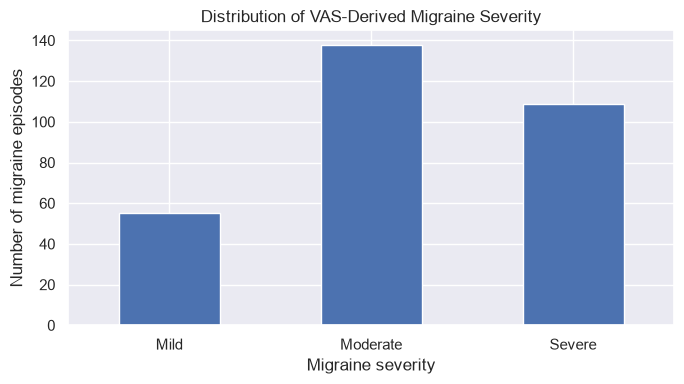

In [51]:
figure, axis = plt.subplots(figsize=(7, 4))

severity_counts.plot(
    kind="bar",
    ax=axis,
)

axis.set_title("Distribution of VAS-Derived Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Number of migraine episodes")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
plt.show()

### 2.2 Missing Data Assessment

Missing values were addressed during the data-cleaning phase prior to EDA. The final modeling dataset was reviewed to confirm that the variables included in the current analysis do not contain unresolved missing values.

In [52]:
# Missing values sanity check
missing_values = model_df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## 3. Physiological Factors and Migraine Severity — RQ2
### ***RQ2: Which physiological factors are most predictive of migraine severity?***

### 3.1 Physiological Factor Prevalence

Calculate the prevalence of each binary physiological factor within Mild, Moderate, and Severe migraine episodes to identify patterns that may be associated with increasing migraine severity.

In [53]:
physiological_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

physiological_prevalence.head(15)

,Feature,Severity,Percent Present
0,Preventive Medication Use,Mild,36.36
1,Preventive Medication Use,Moderate,54.35
2,Preventive Medication Use,Severe,52.29
3,Internal Factor: Stress,Mild,32.73
4,Internal Factor: Stress,Moderate,44.20
5,Internal Factor: Stress,Severe,30.28
6,Internal Factor: Oversleeping,Mild,3.64
7,Internal Factor: Oversleeping,Moderate,1.45
8,Internal Factor: Oversleeping,Severe,1.83
9,Internal Factor: Sleep Deprivation,Mild,20.00


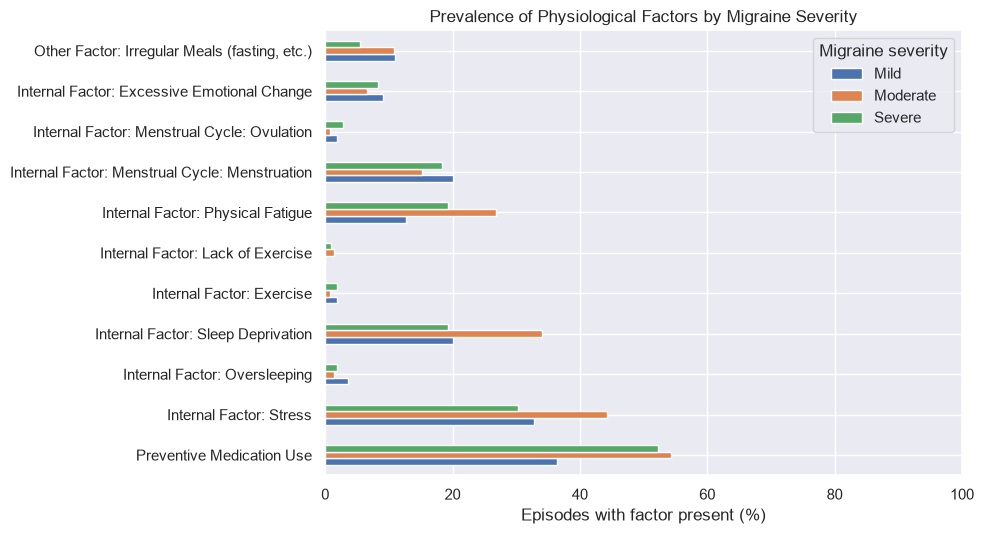

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [54]:
physiological_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Physiological Factors",
)

physiological_prevalence_wide.round(2)

### 3.2 Exercise Participation by Migraine Severity

Examine the distribution of the categorical `Total Exercise` variable across migraine severity levels. Percentages are calculated within each severity category to compare exercise participation patterns.

In [55]:
total_exercise_table = create_ordinal_percentage_table(
    data = model_df,
    variable = "Total Exercise",
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

total_exercise_table.round(2)

Total Exercise,0,1,2
Severity_VAS,,,
Mild,1.82,14.55,83.64
Moderate,1.45,15.94,82.61
Severe,3.67,10.09,86.24


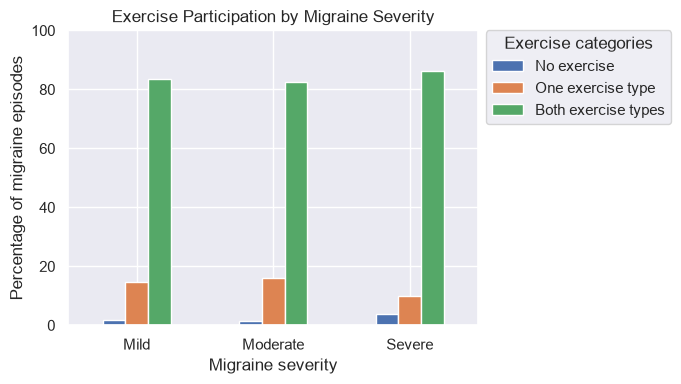

In [56]:
figure, axis = plt.subplots(figsize=(7, 4))

total_exercise_table.plot(
    kind = "bar",
    ax = axis,
)

axis.set_title("Exercise Participation by Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Percentage of migraine episodes")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)

axis.legend(
    title = "Exercise categories",
    labels = [
        "No exercise",
        "One exercise type",
        "Both exercise types",
    ],
    loc = "upper left",  # Anchor point of the legend box
    bbox_to_anchor=(1.02, 1),  # Places legend just outside the right boundary (x=1.02, y=1)
    borderaxespad=0
)

figure.tight_layout()
plt.show()

## 4. Environmental Factors and Migraine Severity — RQ3
### ***RQ3: Which environmental factors are most predictive of migraine severity?***

### 4.1 Environmental Factor Prevalence

Calculate the prevalence of binary environmental factors within each migraine severity category and visualize differences across Mild, Moderate, and Severe episodes.

In [57]:
environmental_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

environmental_prevalence

,Feature,Severity,Percent Present
0,External Factor: Excessive Sunlight,Mild,0.00
1,External Factor: Excessive Sunlight,Moderate,0.72
2,External Factor: Excessive Sunlight,Severe,2.75
3,External Factor: Noise,Mild,1.82
4,External Factor: Noise,Moderate,10.14
5,External Factor: Noise,Severe,8.26
6,External Factor: Inappropriate Lighting,Mild,0.00
7,External Factor: Inappropriate Lighting,Moderate,0.72
8,External Factor: Inappropriate Lighting,Severe,2.75
9,"External Factor: Specific Smell (cosmetics, pe...",Mild,3.64


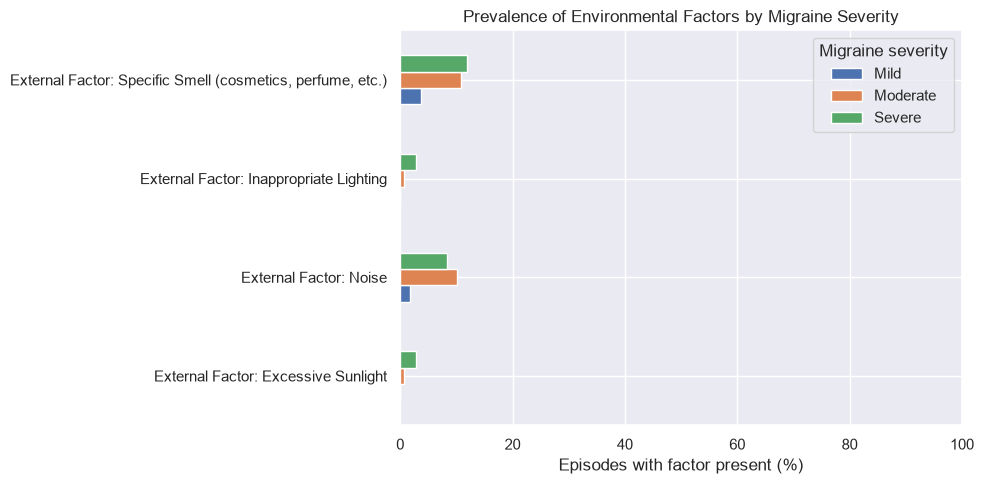

,Mild,Moderate,Severe
Feature,,,
External Factor: Excessive Sunlight,0.00,0.72,2.75
External Factor: Noise,1.82,10.14,8.26
External Factor: Inappropriate Lighting,0.00,0.72,2.75
"External Factor: Specific Smell (cosmetics, perfume, etc.)",3.64,10.87,11.93


In [58]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Environmental Factors",
)

binary_prevalence_wide.round(2)

### 4.2 Time of Day and Migraine Severity

In [59]:
TEMPORAL_FEATURES

model_df[TEMPORAL_FEATURES].head()

,Start_Hour,Time_of_Day
0,10.0,Morning
1,11.0,Morning
2,11.0,Morning
3,20.0,Evening
4,8.0,Morning


#### 4.2.1 Time-of-Day Distribution by Migraine Severity

Examine the distribution of migraine onset across time-of-day categories for Mild, Moderate, and Severe migraine episodes. Percentages are calculated within each severity category to identify potential differences in migraine onset timing across severity levels.

In [60]:
# Calculate time of day percentages within each migraine severity category
time_of_day_table = pd.crosstab(
    model_df[TARGET],
    model_df["Time_of_Day"],
    normalize = "index"
).mul(100).round(2)

# Reorder severity categories to match SEVERITY_ORDER
time_of_day_table = time_of_day_table.reindex(SEVERITY_ORDER)

time_of_day_table


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,30.91,16.36,38.18,14.55
Moderate,22.46,7.25,53.62,16.67
Severe,20.18,6.42,55.96,17.43


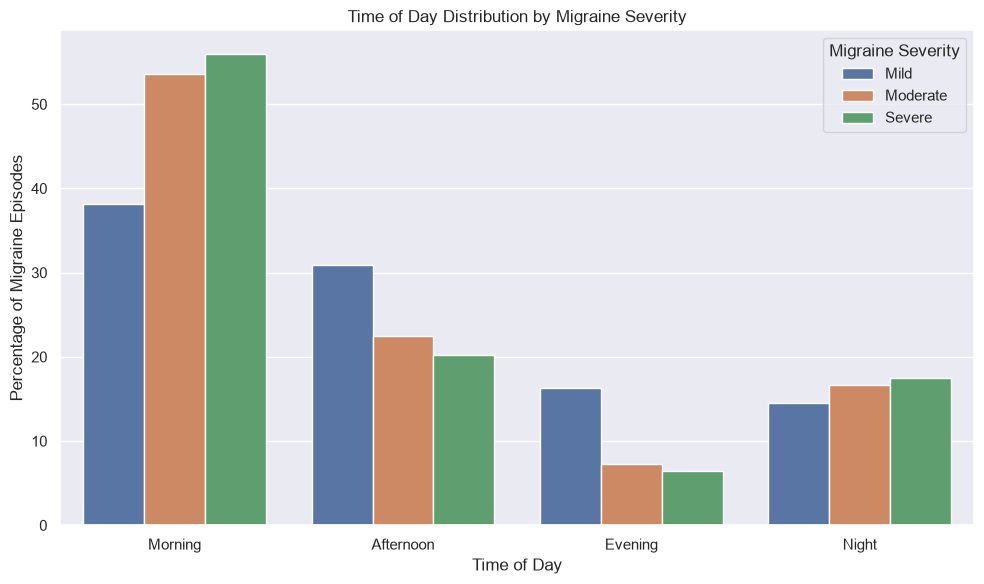

In [61]:
# Define the custom order for the x-axis
TIME_ORDER = ["Morning", "Afternoon", "Evening", "Night"]  # Adjust capitalization if needed to match your dataset values

# Plot time-of-day distribution by migraine severity
time_of_day_plot = (
    time_of_day_table
    .reset_index()
    .melt(
        id_vars=TARGET,
        var_name="Time_of_Day",
        value_name="Percentage"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=time_of_day_plot,
    x="Time_of_Day",
    y="Percentage",
    hue=TARGET,
    hue_order=SEVERITY_ORDER,
    order=TIME_ORDER  # Ensure bars are ordered by defined time of day sequence
)

plt.title("Time of Day Distribution by Migraine Severity")
plt.xlabel("Time of Day")
plt.ylabel("Percentage of Migraine Episodes")
plt.legend(title="Migraine Severity")
plt.tight_layout()
plt.show()

#### 4.2.2 Migraine Start Hour by Severity

Examine the distribution of migraine onset hour across severity categories to determine whether onset timing differs among Mild, Moderate, and Severe migraine episodes.

In [62]:
# Summarize migraine onset hour by severity category
from pickle import TRUE


start_hour_summary = (
    model_df
    .groupby(TARGET, observed = TRUE)["Start_Hour"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reindex(SEVERITY_ORDER)
    .round(2)
)

start_hour_summary

,count,mean,median,std,min,max
Severity_VAS,,,,,,
Mild,55,11.84,12.0,5.70,0.0,22.0
Moderate,138,9.51,9.0,5.03,0.0,21.0
Severe,109,9.09,9.0,5.06,0.0,23.0


#### 4.2.3 Association Between Time of Day and Migraine Severity

Evaluate whether migraine onset time-of-day category is associated with migraine severity using a chi-square test of independence. Cramér's V is calculated to quantify the strength of the association.

In [63]:
# Analyze association between time of day and migraine severity
time_of_day_results, time_of_day_crosstabs = (
    analyze_categorical_associations(
        data=model_df,
        variable="Time_of_Day",
        target=TARGET,
        target_order=SEVERITY_ORDER,
    )
)

# Display categorical association results
print("Statistical Results")
display(pd.DataFrame([time_of_day_results]))

print("Observed Counts")
display(time_of_day_crosstabs["counts"])

print("Row Percentages")
display(time_of_day_crosstabs["row_percentages"])

print("Expected Counts")
display(time_of_day_crosstabs["expected_counts"])

Statistical Results


,Feature,N,Chi-Square,Degrees of Freedom,P-Value,Cramers V,Minimum Expected Count,Expected Counts Below 5,Expected Counts Below 1,Proportion Expected Below 5,Assumptions Met,Status
0,Time_of_Day,302,9.228828,6,0.161112,0.12361,4.735099,1,0,0.083333,True,Test completed


Observed Counts


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,17,9,21,8
Moderate,31,10,74,23
Severe,22,7,61,19


Row Percentages


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,30.91,16.36,38.18,14.55
Moderate,22.46,7.25,53.62,16.67
Severe,20.18,6.42,55.96,17.43


Expected Counts


Time_of_Day,Afternoon,Evening,Morning,Night
Severity_VAS,,,,
Mild,12.748344,4.735099,28.410596,9.105960
Moderate,31.986755,11.880795,71.284768,22.847682
Severe,25.264901,9.384106,56.304636,18.046358


### 4.3 Historical Weather Data Overview

Historical hourly weather observations were matched to migraine episodes based on the participant's study hospital and the hour nearest to migraine onset. The following analyses examine the distributions of barometric pressure, temperature, and relative humidity associated with the recorded migraine episodes.

In [64]:
# Summarize weather conditions associated with migraine episodes
weather_summary = (
    weather_model_df[WEATHER_RAW_FEATURES]
    .describe()
    .T
    .round(2)
)

weather_summary

,count,mean,std,min,25%,50%,75%,max
temperature_2m,302.0,6.82,9.33,-16.1,-1.05,6.90,14.5,25.0
relative_humidity_2m,302.0,66.38,20.55,17.0,51.25,67.50,85.0,100.0
surface_pressure,302.0,1013.22,5.67,993.4,1009.20,1013.75,1016.5,1028.9
pressure_msl,302.0,1021.01,5.88,1000.6,1016.82,1021.55,1024.4,1037.1
wind_speed_10m,302.0,9.22,5.93,0.0,5.40,7.55,11.5,30.1
wind_direction_10m,302.0,195.75,103.95,5.0,96.00,200.50,300.0,360.0


#### 4.3.1 Weather Variable Distributions

The distributions of the historical weather variables were examined to characterize environmental conditions at migraine onset and identify potential skewness, outliers, or unusual values prior to severity-based comparisons.

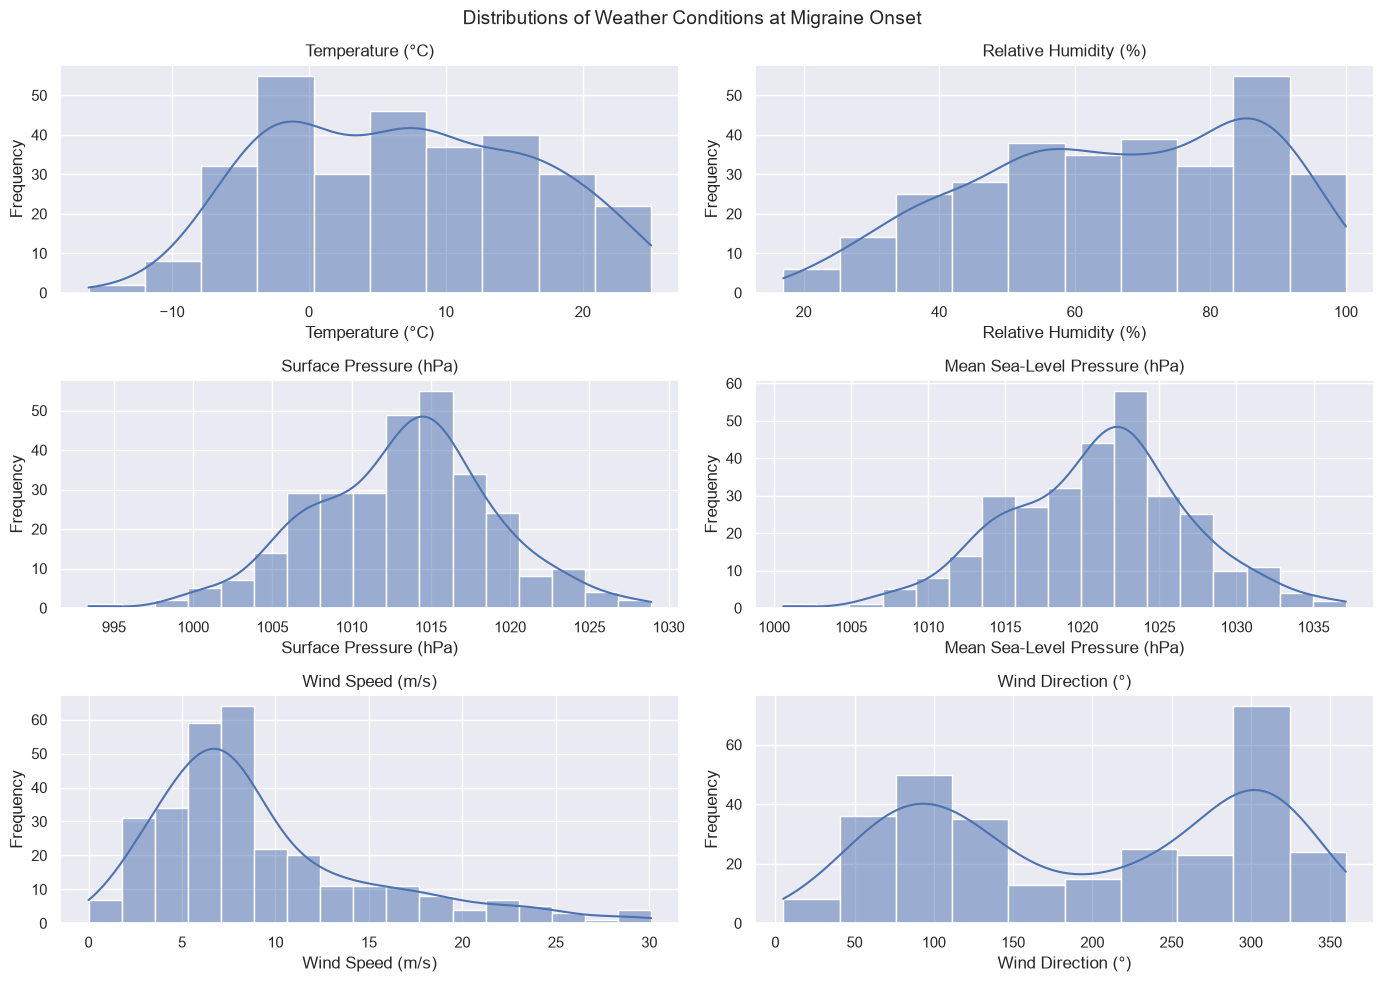

In [65]:
# Define readable labels for weather variables
weather_labels = {
    "temperature_2m": "Temperature (°C)",
    "relative_humidity_2m": "Relative Humidity (%)",
    "pressure_msl": "Mean Sea-Level Pressure (hPa)",
    "surface_pressure": "Surface Pressure (hPa)",
    "wind_speed_10m": "Wind Speed (m/s)",
    "wind_direction_10m": "Wind Direction (°)",
}

# Plot distributions of raw weather variables
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, WEATHER_RAW_FEATURES):
    sns.histplot(
        data=weather_model_df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(weather_labels[feature])
    ax.set_xlabel(weather_labels[feature])
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Weather Conditions at Migraine Onset",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [66]:
# Compare the two pressure measurements
weather_model_df[
    ["pressure_msl", "surface_pressure"]
].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
pressure_msl,302.0,1021.01,5.88,1000.6,1016.82,1021.55,1024.4,1037.1
surface_pressure,302.0,1013.22,5.67,993.4,1009.20,1013.75,1016.5,1028.9


### 4.4 Weather Variables by Migraine Severity

Weather conditions at migraine onset were compared across Mild, Moderate, and Severe migraine episodes. Descriptive statistics and visualizations were used to examine whether temperature, relative humidity, mean sea-level pressure, or surface pressure differed across severity categories.

In [67]:
# Summarize weather variables by migraine severity
weather_by_severity = (
    weather_model_df
    .groupby(TARGET, observed=True)[WEATHER_RAW_FEATURES]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .reindex(SEVERITY_ORDER)
)

weather_by_severity

temperature_2m                                 \
                      count  mean median   std   min   max   
Severity_VAS                                                 
Mild                     55  5.30   4.60  9.28  -9.2  25.0   
Moderate                138  6.81   7.05  9.46 -16.1  25.0   
Severe                  109  7.61   9.10  9.17 -10.3  25.0   

             relative_humidity_2m                       ... wind_speed_10m  \
                            count   mean median    std  ...         median   
Severity_VAS                                            ...                  
Mild                           55  61.78   62.0  19.91  ...           7.70   
Moderate                      138  66.75   67.5  20.24  ...           7.25   
Severe                        109  68.23   71.0  21.09  ...           7.90   

                              wind_direction_10m                             \
               std  min   max              count    mean median     std min   
Severity_VAS                                                                  
Mild          7.02  0.0  28.6                 55  212.20  246.0  103.07  12   
Moderate      5.39  1.3  28.9                138  194.54  199.5  103.59  11   
Severe        5.93  0.5  30.1                109  188.96  155.0  104.92   5   

                   
              max  
Severity_VAS       
Mild          346  
Moderate      360  
Severe        355  

[3 rows x 36 columns]

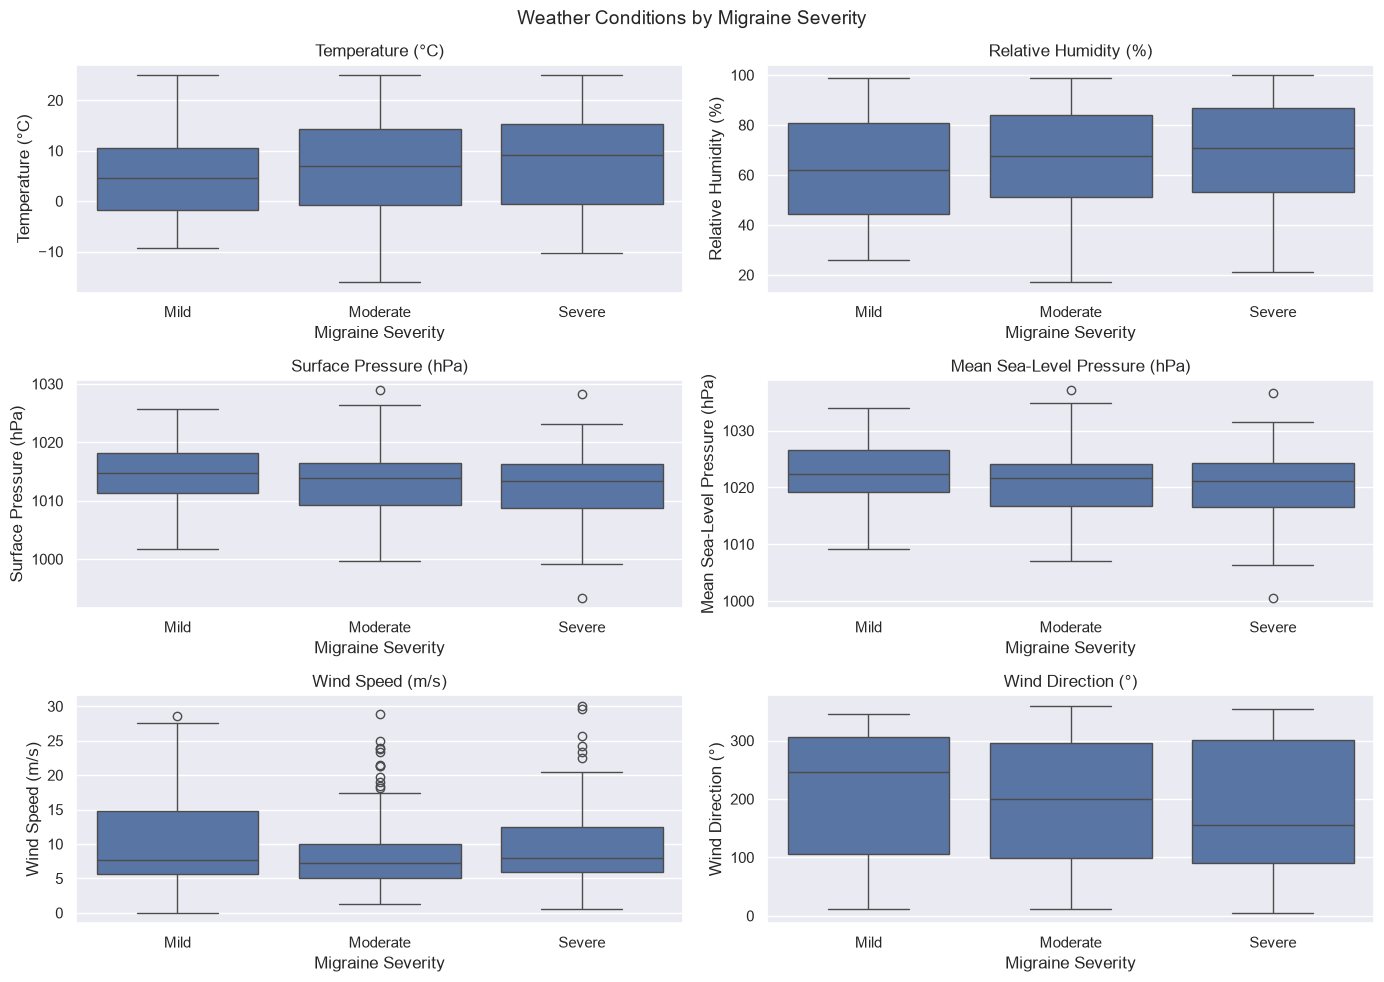

In [68]:
# Compare weather distributions across migraine severity
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, WEATHER_RAW_FEATURES):
    sns.boxplot(
        data=weather_model_df,
        x=TARGET,
        y=feature,
        order=SEVERITY_ORDER,
        ax=ax
    )

    ax.set_title(weather_labels[feature])
    ax.set_xlabel("Migraine Severity")
    ax.set_ylabel(weather_labels[feature])

plt.suptitle(
    "Weather Conditions by Migraine Severity",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation

Descriptive comparisons suggest several potential weather-related patterns across migraine severity categories. Temperature and relative humidity generally increased with migraine severity, with Severe episodes occurring under warmer and more humid conditions than Mild episodes. In contrast, atmospheric pressure generally decreased as migraine severity increased. Both mean sea-level pressure and surface pressure showed this pattern.

These differences are descriptive and do not establish statistically significant associations with migraine severity. Formal statistical testing is conducted in Section 4.6.

### 4.5 Weather Changes and Migraine Severity

Changes in temperature and atmospheric pressure during the 24 hours preceding migraine onset were examined to determine whether recent changes in weather conditions differed across migraine severity categories. Positive values indicate an increase over the preceding 24 hours, while negative values indicate a decrease.

In [69]:
wind_cols = [
    "wind_speed_10m",
    "wind_direction_10m"
]

for col in wind_cols:
    print(f"{col}: {col in weather_model_df.columns}")

wind_speed_10m: True
wind_direction_10m: True


In [70]:
# Confirm weather-change variables are available
# Confirm which weather-change variables are actually present in the enriched dataset
weather_model_df[
    WEATHER_CHANGE_FEATURES_ALL
].isna().sum()

relative_humidity_change_24h     1
temperature_change_24h           1
pressure_msl_change_24h          1
surface_pressure_change_24h      1
wind_speed_10m_change_24h        1
wind_direction_10m_change_24h    1
relative_humidity_change_48h     2
temperature_change_48h           2
pressure_msl_change_48h          2
surface_pressure_change_48h      2
wind_speed_10m_change_48h        2
wind_direction_10m_change_48h    2
relative_humidity_change_72h     2
temperature_change_72h           2
pressure_msl_change_72h          2
surface_pressure_change_72h      2
wind_speed_10m_change_72h        2
wind_direction_10m_change_72h    2
dtype: int64

#### 4.5.1 24-Hour Weather Changes

In [71]:
# Check missing values in 24-hour and 48 hour weather-change variables
weather_model_df[
    WEATHER_CHANGE_24H_FEATURES
].isna().sum()

relative_humidity_change_24h     1
temperature_change_24h           1
pressure_msl_change_24h          1
surface_pressure_change_24h      1
wind_speed_10m_change_24h        1
wind_direction_10m_change_24h    1
dtype: int64

In [72]:
# Identify migraine episode with missing 24-hour weather-change data
weather_model_df.loc[
    weather_model_df[WEATHER_CHANGE_24H_FEATURES].isna().any(axis=1),
    [
        "Registration No.",
        "Start Time",
        "Weather_Hour",
        "hospital",
        TARGET,
        *WEATHER_CHANGE_24H_FEATURES,
    ]
]

,Registration No.,Start Time,Weather_Hour,hospital,Severity_VAS,relative_humidity_change_24h,temperature_change_24h,pressure_msl_change_24h,surface_pressure_change_24h,wind_speed_10m_change_24h,wind_direction_10m_change_24h
68,cmc-0002,2014-08-25 14:00:00,2014-08-25 14:00:00,Uijeongbu,Severe,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
# Summarize 24-hour weather changes by migraine severity
weather_changes_by_severity = (
    weather_model_df
    .groupby(TARGET, observed=True)[WEATHER_CHANGE_24H_FEATURES]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .reindex(SEVERITY_ORDER)
)

weather_changes_by_severity

relative_humidity_change_24h                                  \
                                    count  mean median    std   min   max   
Severity_VAS                                                                
Mild                                   55 -0.35    2.0  19.48 -62.0  28.0   
Moderate                              138 -0.45    0.0  17.28 -66.0  48.0   
Severe                                108 -1.20    0.5  21.36 -64.0  53.0   

             temperature_change_24h                     ...  \
                              count  mean median   std  ...   
Severity_VAS                                            ...   
Mild                             55  0.31   0.80  3.36  ...   
Moderate                        138 -0.08   0.50  2.99  ...   
Severe                          108 -0.23   0.15  3.04  ...   

             wind_speed_10m_change_24h                    \
                                median   std   min   max   
Severity_VAS                                               
Mild                              -0.3  7.32 -21.2  16.4   
Moderate                          -0.3  6.94 -19.3  23.4   
Severe                             0.1  7.00 -15.1  23.0   

             wind_direction_10m_change_24h                                    
                                     count  mean median    std    min    max  
Severity_VAS                                                                  
Mild                                    55 -7.00    0.0  92.31 -162.0  179.0  
Moderate                               138  7.47   -1.5  88.52 -168.0  178.0  
Severe                                 108 -1.99    0.5  83.81 -180.0  162.0  

[3 rows x 36 columns]

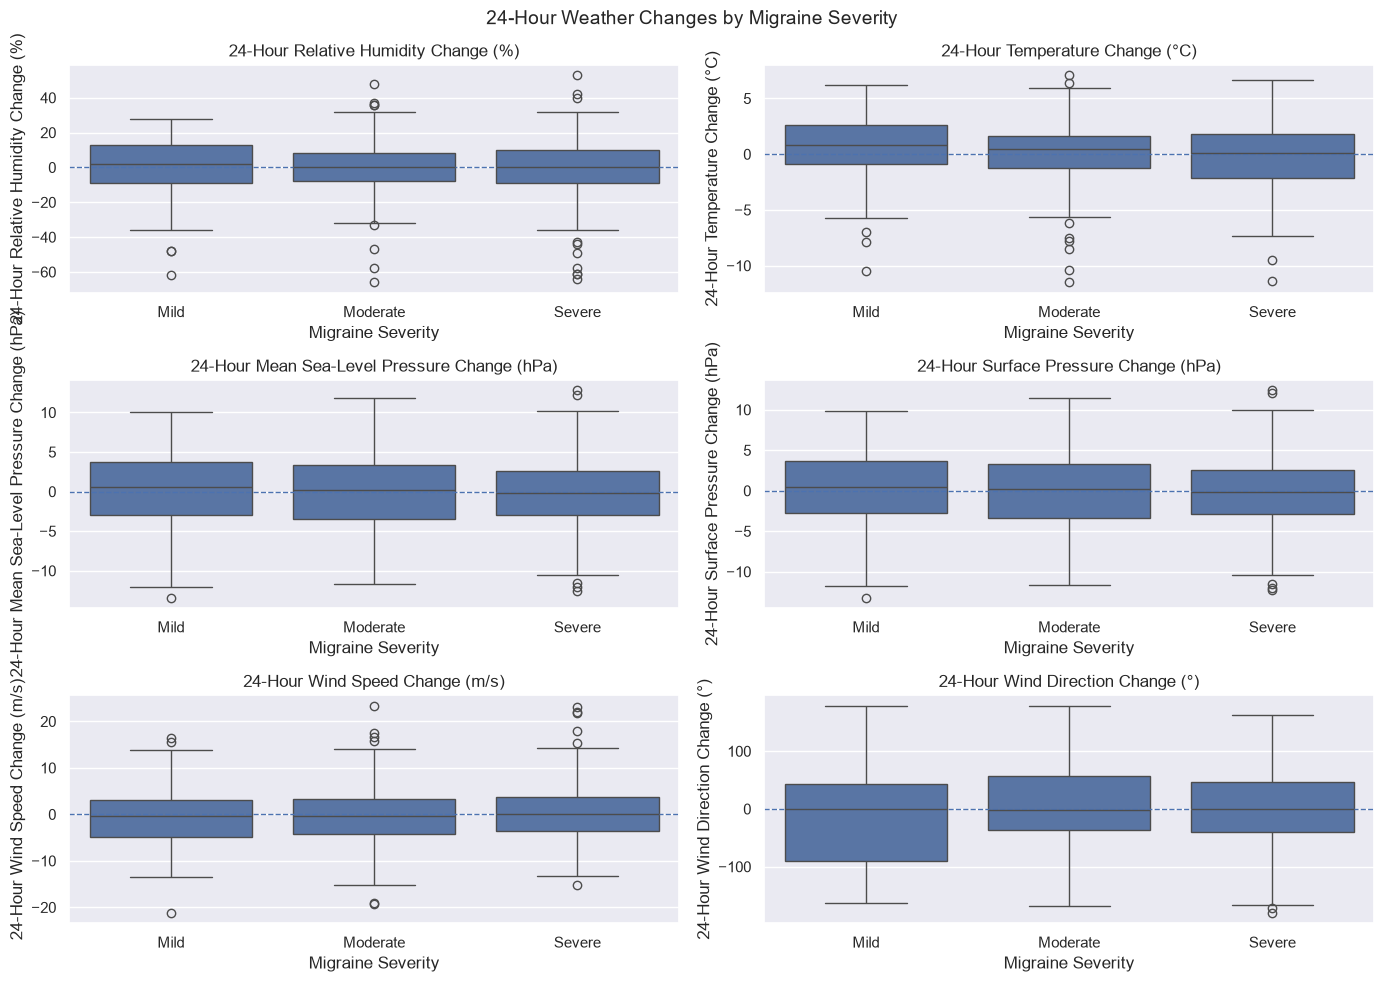

In [101]:
# Define readable labels for weather-change variables
weather_change_24h_labels = {
    "relative_humidity_change_24h": "24-Hour Relative Humidity Change (%)",
    "temperature_change_24h": "24-Hour Temperature Change (°C)",
    "pressure_msl_change_24h": "24-Hour Mean Sea-Level Pressure Change (hPa)",
    "surface_pressure_change_24h": "24-Hour Surface Pressure Change (hPa)",
    "wind_speed_10m_change_24h": "24-Hour Wind Speed Change (m/s)",
    "wind_direction_10m_change_24h": "24-Hour Wind Direction Change (°)",
}

# Plot 24-hour weather changes by migraine severity
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,  # Adjusted for 6 features (3x2 grid)
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, WEATHER_CHANGE_24H_FEATURES):
    sns.boxplot(
        data=weather_model_df,
        x=TARGET,
        y=feature,
        order=SEVERITY_ORDER,
        ax=ax
    )

    # Reference line representing no change
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(weather_change_24h_labels[feature])
    ax.set_xlabel("Migraine Severity")
    ax.set_ylabel(weather_change_24h_labels[feature])

plt.suptitle(
    "24-Hour Weather Changes by Migraine Severity",
    fontsize=14
)

plt.tight_layout()
plt.show()

One Severe migraine episode lacked 24-hour weather-change measurements because the corresponding weather observation from 24 hours before migraine onset was unavailable. The episode was retained for analyses using available variables and excluded only from analyses requiring 24-hour weather-change measurements.

#### 4.5.2 48-Hour Weather Changes

In [75]:
# Check missing values in 48-hour weather-change variables
weather_model_df[
    WEATHER_CHANGE_48H_FEATURES
].isna().sum()

relative_humidity_change_48h     2
temperature_change_48h           2
pressure_msl_change_48h          2
surface_pressure_change_48h      2
wind_speed_10m_change_48h        2
wind_direction_10m_change_48h    2
dtype: int64

In [76]:
# Identify migraine episode with missing 48-hour weather-change data
weather_model_df.loc[
    weather_model_df[WEATHER_CHANGE_48H_FEATURES].isna().any(axis=1),
    [
        "Registration No.",
        "Start Time",
        "Weather_Hour",
        "hospital",
        TARGET,
        *WEATHER_CHANGE_48H_FEATURES,
    ]
]

,Registration No.,Start Time,Weather_Hour,hospital,Severity_VAS,relative_humidity_change_48h,temperature_change_48h,pressure_msl_change_48h,surface_pressure_change_48h,wind_speed_10m_change_48h,wind_direction_10m_change_48h
68,cmc-0002,2014-08-25 14:00:00,2014-08-25 14:00:00,Uijeongbu,Severe,NaN,NaN,NaN,NaN,NaN,NaN
218,cmc-0004,2014-08-26 10:00:00,2014-08-26 10:00:00,Uijeongbu,Moderate,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# Summarize 48-hour weather changes by migraine severity
weather_changes_by_severity = (
    weather_model_df
    .groupby(TARGET, observed=True)[WEATHER_CHANGE_48H_FEATURES]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .reindex(SEVERITY_ORDER)
)

weather_changes_by_severity

relative_humidity_change_48h                                  \
                                    count  mean median    std   min   max   
Severity_VAS                                                                
Mild                                   55 -5.11   -4.0  23.65 -59.0  43.0   
Moderate                              137 -1.62    2.0  20.51 -67.0  70.0   
Severe                                108 -0.46    0.0  23.63 -73.0  51.0   

             temperature_change_48h                     ...  \
                              count  mean median   std  ...   
Severity_VAS                                            ...   
Mild                             55 -0.63    0.0  4.41  ...   
Moderate                        137 -0.38   -0.1  3.97  ...   
Severe                          108 -0.52   -0.4  3.70  ...   

             wind_speed_10m_change_48h                    \
                                median   std   min   max   
Severity_VAS                                               
Mild                             -0.40  8.43 -20.4  18.9   
Moderate                         -0.40  8.13 -29.9  20.7   
Severe                            0.75  7.83 -20.1  20.9   

             wind_direction_10m_change_48h                                      
                                     count   mean median     std    min    max  
Severity_VAS                                                                    
Mild                                    55 -14.84  -27.0  104.94 -180.0  174.0  
Moderate                               137 -12.10  -14.0   99.31 -179.0  177.0  
Severe                                 108  11.01    1.5   98.04 -177.0  179.0  

[3 rows x 36 columns]

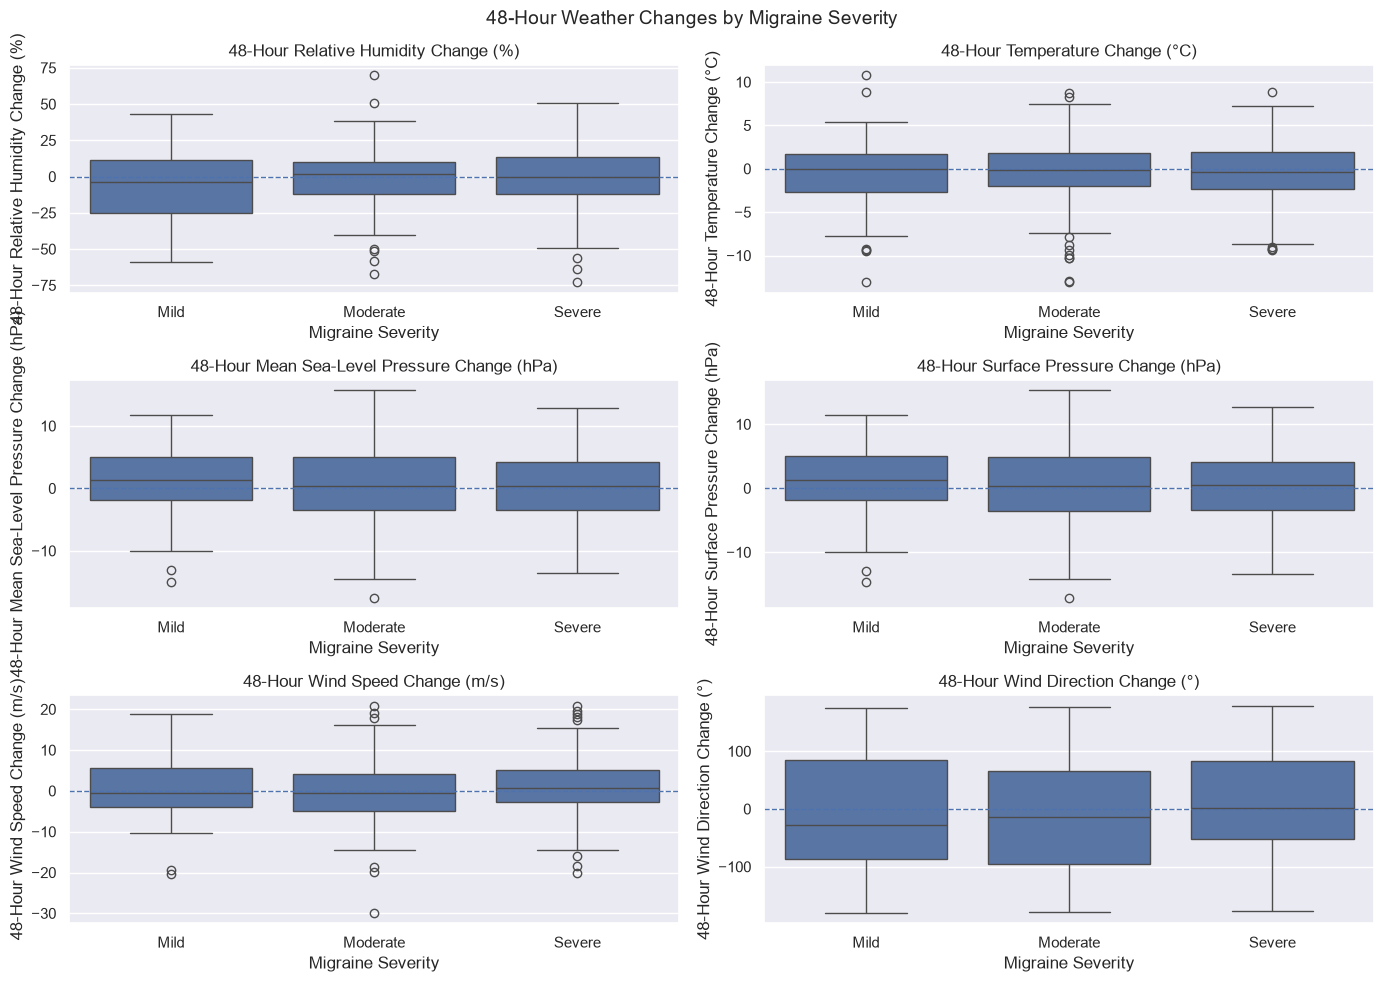

In [102]:
# Define readable labels for weather-change variables
weather_change_48h_labels = {
    "relative_humidity_change_48h": "48-Hour Relative Humidity Change (%)",
    "temperature_change_48h": "48-Hour Temperature Change (°C)",
    "pressure_msl_change_48h": "48-Hour Mean Sea-Level Pressure Change (hPa)",
    "surface_pressure_change_48h": "48-Hour Surface Pressure Change (hPa)",
    "wind_speed_10m_change_48h": "48-Hour Wind Speed Change (m/s)",
    "wind_direction_10m_change_48h": "48-Hour Wind Direction Change (°)",
}

# Plot 48-hour weather changes by migraine severity
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,  # Adjusted for 6 features (3x2 grid)
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, WEATHER_CHANGE_48H_FEATURES):
    sns.boxplot(
        data=weather_model_df,
        x=TARGET,
        y=feature,
        order=SEVERITY_ORDER,
        ax=ax
    )

    # Reference line representing no change
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(weather_change_48h_labels[feature])
    ax.set_xlabel("Migraine Severity")
    ax.set_ylabel(weather_change_48h_labels[feature])

plt.suptitle(
    "48-Hour Weather Changes by Migraine Severity",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### 4.5.2 72-Hour Weather Changes

In [79]:
# Check missing values in 72-hour weather-change variables
weather_model_df[
    WEATHER_CHANGE_72H_FEATURES
].isna().sum()

relative_humidity_change_72h     2
temperature_change_72h           2
pressure_msl_change_72h          2
surface_pressure_change_72h      2
wind_speed_10m_change_72h        2
wind_direction_10m_change_72h    2
dtype: int64

In [80]:
# Identify migraine episode with missing 72-hour weather-change data
weather_model_df.loc[
    weather_model_df[WEATHER_CHANGE_72H_FEATURES].isna().any(axis=1),
    [
        "Registration No.",
        "Start Time",
        "Weather_Hour",
        "hospital",
        TARGET,
        *WEATHER_CHANGE_72H_FEATURES,
    ]
]

,Registration No.,Start Time,Weather_Hour,hospital,Severity_VAS,relative_humidity_change_72h,temperature_change_72h,pressure_msl_change_72h,surface_pressure_change_72h,wind_speed_10m_change_72h,wind_direction_10m_change_72h
68,cmc-0002,2014-08-25 14:00:00,2014-08-25 14:00:00,Uijeongbu,Severe,NaN,NaN,NaN,NaN,NaN,NaN
218,cmc-0004,2014-08-26 10:00:00,2014-08-26 10:00:00,Uijeongbu,Moderate,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
# Summarize 72-hour weather changes by migraine severity
weather_changes_by_severity = (
    weather_model_df
    .groupby(TARGET, observed=True)[WEATHER_CHANGE_72H_FEATURES]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .reindex(SEVERITY_ORDER)
)

weather_changes_by_severity

relative_humidity_change_72h                                  \
                                    count  mean median    std   min   max   
Severity_VAS                                                                
Mild                                   55 -3.18   -2.0  22.68 -61.0  34.0   
Moderate                              137  1.28    1.0  20.62 -46.0  74.0   
Severe                                108 -0.09    0.0  21.10 -59.0  42.0   

             temperature_change_72h                     ...  \
                              count  mean median   std  ...   
Severity_VAS                                            ...   
Mild                             55 -0.23   -0.4  4.33  ...   
Moderate                        137 -0.81   -0.4  4.49  ...   
Severe                          108 -0.59   -0.7  4.31  ...   

             wind_speed_10m_change_72h                    \
                                median   std   min   max   
Severity_VAS                                               
Mild                              -0.1  9.24 -17.6  22.8   
Moderate                           0.1  7.03 -17.1  18.4   
Severe                             1.6  7.23 -17.5  20.2   

             wind_direction_10m_change_72h                                      
                                     count   mean median     std    min    max  
Severity_VAS                                                                    
Mild                                    55  -3.78  -28.0  102.43 -179.0  176.0  
Moderate                               137 -23.31  -22.0   99.74 -178.0  179.0  
Severe                                 108   0.04    3.0  100.10 -178.0  179.0  

[3 rows x 36 columns]

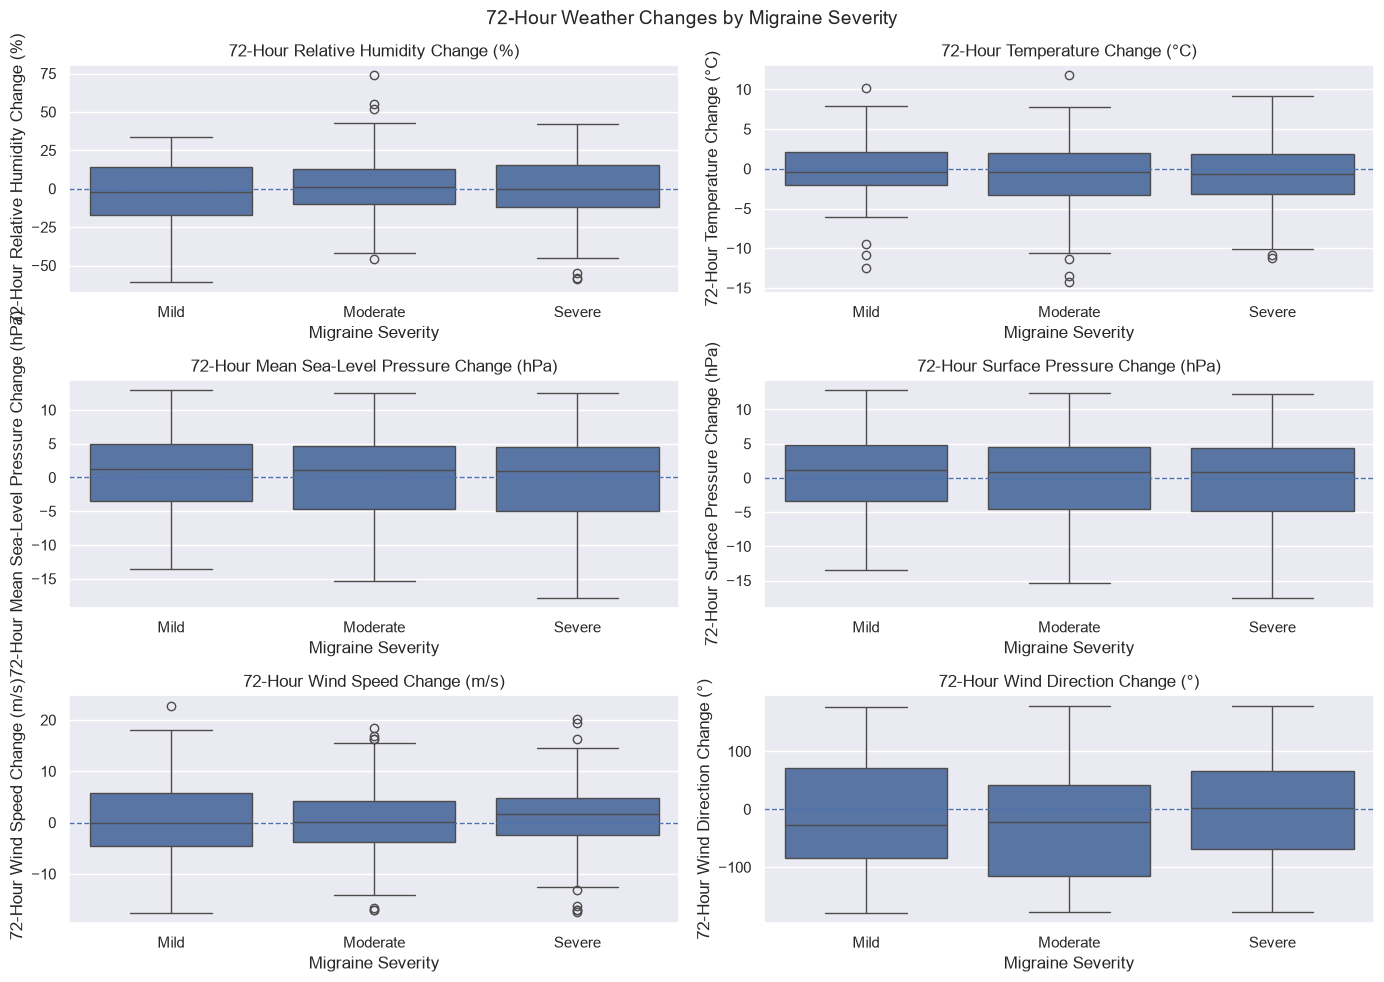

In [103]:
# Define readable labels for weather-change variables
weather_change_72h_labels = {
    "relative_humidity_change_72h": "72-Hour Relative Humidity Change (%)",
    "temperature_change_72h": "72-Hour Temperature Change (°C)",
    "pressure_msl_change_72h": "72-Hour Mean Sea-Level Pressure Change (hPa)",
    "surface_pressure_change_72h": "72-Hour Surface Pressure Change (hPa)",
    "wind_speed_10m_change_72h": "72-Hour Wind Speed Change (m/s)",
    "wind_direction_10m_change_72h": "72-Hour Wind Direction Change (°)",
}

# Plot 72-hour weather changes by migraine severity
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,  # Adjusted for 6 features (3x2 grid)
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, WEATHER_CHANGE_72H_FEATURES):
    sns.boxplot(
        data=weather_model_df,
        x=TARGET,
        y=feature,
        order=SEVERITY_ORDER,
        ax=ax
    )

    # Reference line representing no change
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(weather_change_72h_labels[feature])
    ax.set_xlabel("Migraine Severity")
    ax.set_ylabel(weather_change_72h_labels[feature])

plt.suptitle(
    "72-Hour Weather Changes by Migraine Severity",
    fontsize=14
)

plt.tight_layout()
plt.show()

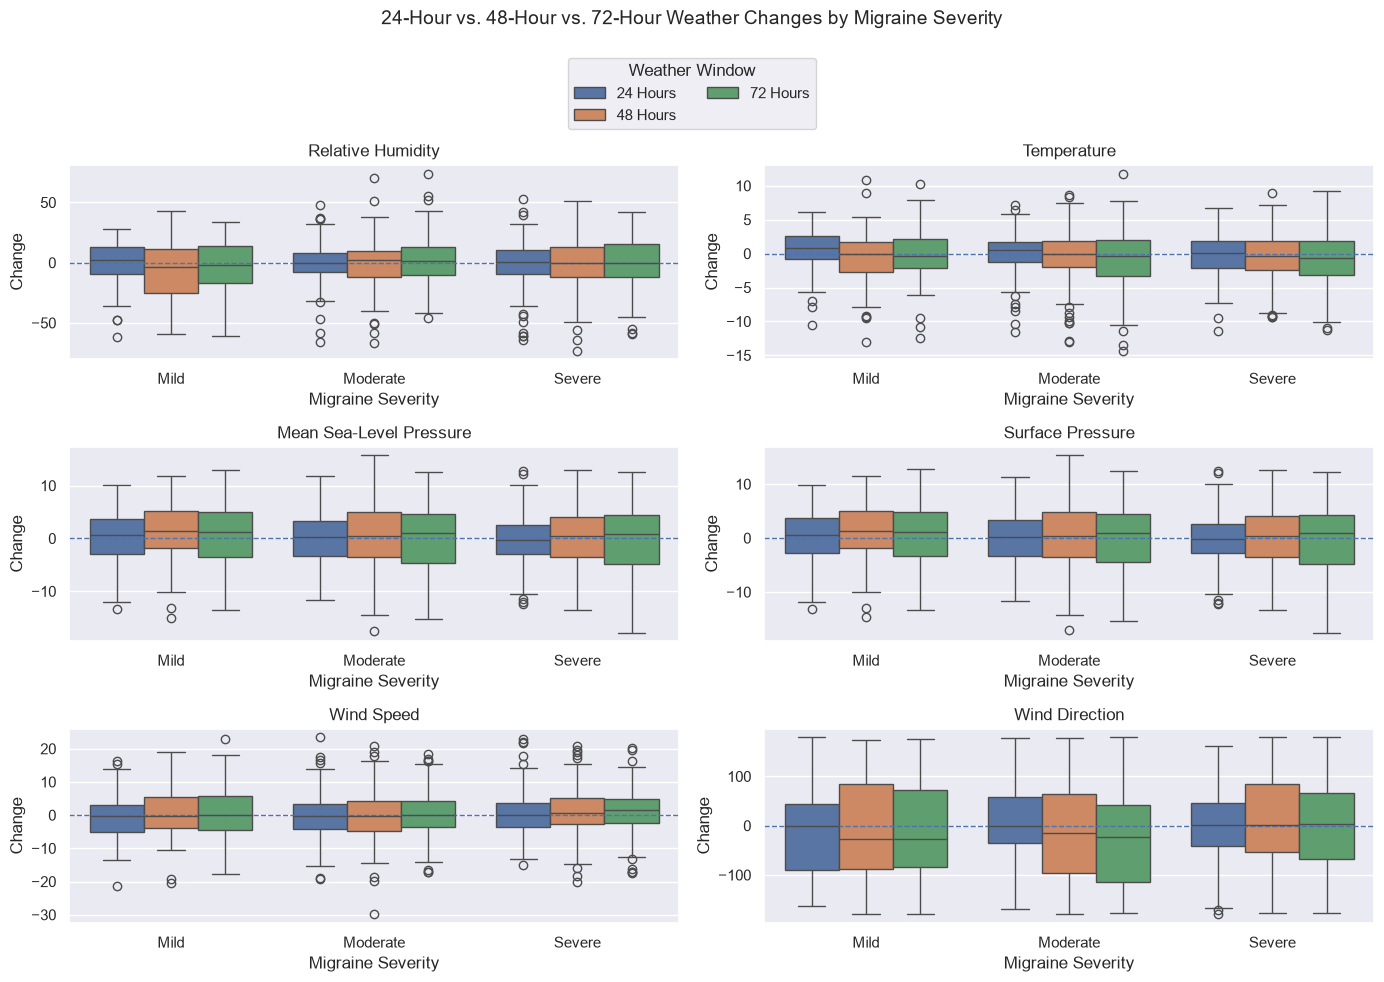

In [104]:
# Pair 24, 48, 72-hour weather-change features
weather_change_pairs = {
    "Relative Humidity": (
        "relative_humidity_change_24h",
        "relative_humidity_change_48h",
        "relative_humidity_change_72h",
    ),
    "Temperature": (
        "temperature_change_24h",
        "temperature_change_48h",
        "temperature_change_72h",
    ),
    "Mean Sea-Level Pressure": (
        "pressure_msl_change_24h",
        "pressure_msl_change_48h",
        "pressure_msl_change_72h",
    ),
    "Surface Pressure": (
        "surface_pressure_change_24h",
        "surface_pressure_change_48h",
        "surface_pressure_change_72h",
    ),
    "Wind Speed": (
        "wind_speed_10m_change_24h",
        "wind_speed_10m_change_48h",
        "wind_speed_10m_change_72h",
    ),
    "Wind Direction": (
        "wind_direction_10m_change_24h",
        "wind_direction_10m_change_48h",
        "wind_direction_10m_change_72h",
    ),
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,  # Adjusted for 6 features (3x2 grid)
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, (label, features) in zip(
    axes,
    weather_change_pairs.items()
):
    feature_24h, feature_48h, feature_72h = features

    plot_df = weather_model_df[
        [TARGET, feature_24h, feature_48h, feature_72h]
    ].melt(
        id_vars=TARGET,
        value_vars=[feature_24h, feature_48h, feature_72h],
        var_name="Window",
        value_name="Change",
    )

    plot_df["Window"] = plot_df["Window"].map({
        feature_24h: "24 Hours",
        feature_48h: "48 Hours",
        feature_72h: "72 Hours",
    })

    sns.boxplot(
        data=plot_df,
        x=TARGET,
        y="Change",
        hue="Window",
        order=SEVERITY_ORDER,
        ax=ax,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(label)
    ax.set_xlabel("Migraine Severity")
    ax.set_ylabel("Change")

    # Remove individual subplot legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Weather Window",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
)

plt.suptitle(
    "24-Hour vs. 48-Hour vs. 72-Hour Weather Changes by Migraine Severity",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

### 4.6 Environmental Factor Associations with Migraine Severity

Associations between continuous environmental variables and migraine severity were evaluated using the Kruskal–Wallis test. This nonparametric test was used to determine whether the distributions of weather variables differed across Mild, Moderate, and Severe migraine episodes.

Raw weather conditions at migraine onset and weather changes over the preceding 24- and 48-hour periods were evaluated separately. Because multiple environmental variables were tested, Benjamini–Hochberg correction was applied to control the false discovery rate.

In [84]:
# Test continuous weather variables across migraine severity groups
environmental_results = []

for feature in WEATHER_FEATURES:

    groups = [
        weather_model_df.loc[
            weather_model_df[TARGET] == severity,
            feature
        ].dropna()
        for severity in SEVERITY_ORDER
    ]

    # Kruskal-Wallis test
    statistic, p_value = kruskal(*groups)

    # Sample size and number of severity groups
    n = sum(len(group) for group in groups)
    k = len(groups)

    # Calculate epsilon-squared effect size
    epsilon_squared = (
        (statistic - k + 1) / (n - k)
        if n > k
        else np.nan
    )

    # Epsilon-squared can be slightly negative when the effect is near zero
    epsilon_squared = max(0, epsilon_squared)

    environmental_results.append({
        "Feature": feature,
        "N": n,
        "Kruskal-Wallis H": statistic,
        "P-Value": p_value,
        "Epsilon-Squared": epsilon_squared,
    })

environmental_results = pd.DataFrame(
    environmental_results
)

environmental_results

,Feature,N,Kruskal-Wallis H,P-Value,Epsilon-Squared
0,temperature_2m,302,2.614834,0.270518,0.002056
1,relative_humidity_2m,302,4.401648,0.110712,0.008032
2,surface_pressure,302,4.219642,0.121260,0.007424
3,pressure_msl,302,4.493113,0.105763,0.008338
4,wind_speed_10m,302,3.003325,0.222760,0.003356
5,wind_direction_10m,302,1.485114,0.475895,0.000000
6,relative_humidity_change_24h,301,0.389088,0.823210,0.000000
7,temperature_change_24h,301,2.432378,0.296357,0.001451
8,pressure_msl_change_24h,301,1.152390,0.562033,0.000000
9,surface_pressure_change_24h,301,1.163233,0.558994,0.000000


In [85]:
# Apply Benjamini-Hochberg correction for multiple comparisons
environmental_results = add_benjamini_hochberg_correction(
    environmental_results
)

environmental_results

,Feature,N,Kruskal-Wallis H,P-Value,Epsilon-Squared,Adjusted P-Value,Significant After FDR
0,temperature_2m,302,2.614834,0.270518,0.002056,0.677515,False
1,relative_humidity_2m,302,4.401648,0.110712,0.008032,0.677515,False
2,surface_pressure,302,4.219642,0.121260,0.007424,0.677515,False
3,pressure_msl,302,4.493113,0.105763,0.008338,0.677515,False
4,wind_speed_10m,302,3.003325,0.222760,0.003356,0.677515,False
5,wind_direction_10m,302,1.485114,0.475895,0.000000,0.859580,False
6,relative_humidity_change_24h,301,0.389088,0.823210,0.000000,0.902984,False
7,temperature_change_24h,301,2.432378,0.296357,0.001451,0.677515,False
8,pressure_msl_change_24h,301,1.152390,0.562033,0.000000,0.859580,False
9,surface_pressure_change_24h,301,1.163233,0.558994,0.000000,0.859580,False


In [86]:
environmental_results["Effect Size"] = (
    environmental_results["Epsilon-Squared"]
    .apply(interpret_epsilon_squared)
)

environmental_results = environmental_results[
    [
        "Feature",
        "N",
        "Kruskal-Wallis H",
        "P-Value",
        "Adjusted P-Value",
        "Epsilon-Squared",
        "Effect Size",
        "Significant After FDR",
    ]
]

environmental_results.round(4)

,Feature,N,Kruskal-Wallis H,P-Value,Adjusted P-Value,Epsilon-Squared,Effect Size,Significant After FDR
0,temperature_2m,302,2.6148,0.2705,0.6775,0.0021,Negligible,False
1,relative_humidity_2m,302,4.4016,0.1107,0.6775,0.0080,Negligible,False
2,surface_pressure,302,4.2196,0.1213,0.6775,0.0074,Negligible,False
3,pressure_msl,302,4.4931,0.1058,0.6775,0.0083,Negligible,False
4,wind_speed_10m,302,3.0033,0.2228,0.6775,0.0034,Negligible,False
5,wind_direction_10m,302,1.4851,0.4759,0.8596,0.0000,Negligible,False
6,relative_humidity_change_24h,301,0.3891,0.8232,0.9030,0.0000,Negligible,False
7,temperature_change_24h,301,2.4324,0.2964,0.6775,0.0015,Negligible,False
8,pressure_msl_change_24h,301,1.1524,0.5620,0.8596,0.0000,Negligible,False
9,surface_pressure_change_24h,301,1.1632,0.5590,0.8596,0.0000,Negligible,False


#### Interpretation

None of the raw weather variables or the 24-, 48-, or 72-hour weather-change variables demonstrated statistically significant differences across Mild, Moderate, and Severe migraine episodes based on Kruskal–Wallis testing. No environmental variable remained significant after Benjamini–Hochberg correction for multiple comparisons.

Among the raw weather variables, mean sea-level pressure, relative humidity, and surface pressure produced the smallest unadjusted p-values, although none reached the conventional significance threshold. The 24-, 48-, and 72-hour weather-change variables generally showed weaker evidence of differences among severity groups.

These findings suggest that individual weather variables do not strongly distinguish migraine severity when evaluated independently. However, the weather variables will be retained for multivariable modeling because their predictive contribution may emerge through interactions with physiological, temporal, or other environmental factors.

## 5. Lifestyle and Behavioral Factors

### 5.1 Lifestyle Factor Prevalence

Calculate the prevalence of binary lifestyle factors within each migraine severity category and compare their distributions across severity levels.

In [87]:
lifestyle_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

lifestyle_prevalence

,Feature,Severity,Percent Present
0,Other Factor: Excessive Alcohol,Mild,5.45
1,Other Factor: Excessive Alcohol,Moderate,7.25
2,Other Factor: Excessive Alcohol,Severe,7.34
3,Other Factor: Overeating,Mild,5.45
4,Other Factor: Overeating,Moderate,2.90
5,Other Factor: Overeating,Severe,6.42
6,Other Factor: Excessive Caffeine,Mild,0.00
7,Other Factor: Excessive Caffeine,Moderate,0.72
8,Other Factor: Excessive Caffeine,Severe,4.59
9,Other Factor: Excessive Smoking,Mild,1.82


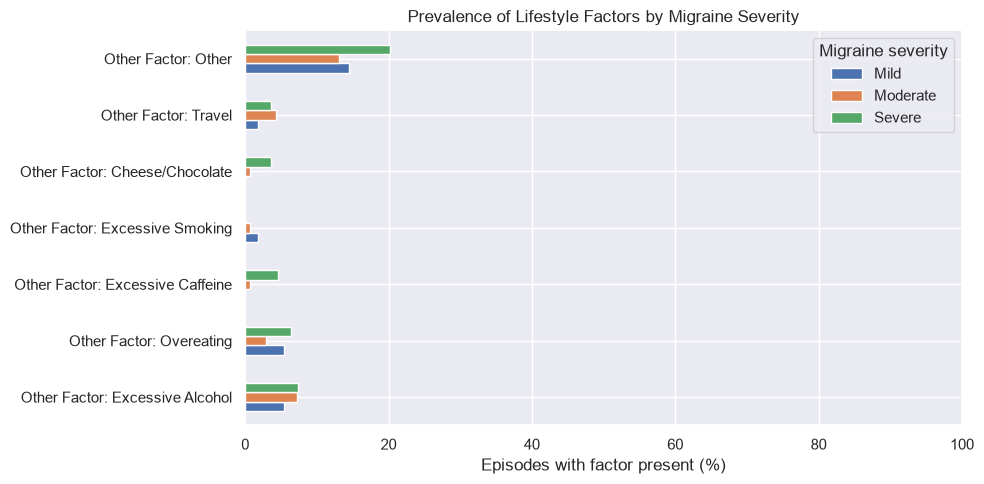

,Mild,Moderate,Severe
Feature,,,
Other Factor: Excessive Alcohol,5.45,7.25,7.34
Other Factor: Overeating,5.45,2.90,6.42
Other Factor: Excessive Caffeine,0.00,0.72,4.59
Other Factor: Excessive Smoking,1.82,0.72,0.00
Other Factor: Cheese/Chocolate,0.00,0.72,3.67
Other Factor: Travel,1.82,4.35,3.67
Other Factor: Other,14.55,13.04,20.18


In [88]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Lifestyle Factors",
)

binary_prevalence_wide.round(2)

## 6. Overall Predictor Associations — RQ1
### ***RQ1: To what extent can migraine severity be predicted using physiological and environmental factors?***

This exploratory analysis examines preliminary relationships between the candidate predictors and migraine severity. Predictive performance for RQ1 will be formally evaluated during model development.

### 6.1 Comparison of All Binary Predictors

Visualize physiological, environmental, and lifestyle binary predictors together to identify broader prevalence patterns across migraine severity categories.

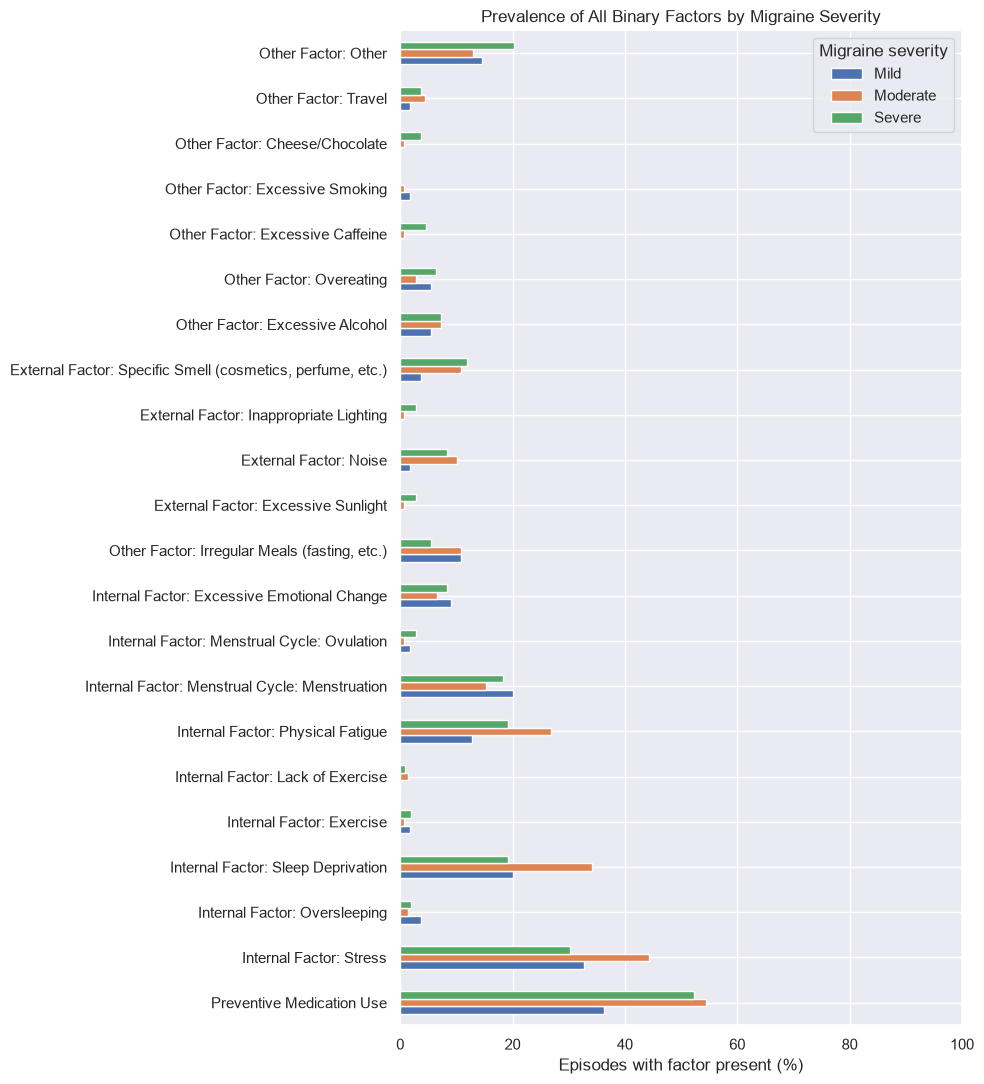

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [89]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES + ENVIRONMENTAL_BINARY_FEATURES + LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "All Binary Factors",
)

binary_prevalence_wide.round(2)

### 6.2 Binary Feature Associations with Migraine Severity

Evaluate the association between each physiological, environmental, and lifestyle binary feature and migraine severity using chi-square tests and Cramér's V effect sizes. Apply the Benjamini-Hochberg procedure to control the false discovery rate across multiple comparisons.

In [90]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

# Analyze associations between binary features and migraine severity
binary_test_results, binary_crosstabs = analyze_binary_associations(
    data = model_df,
    variables = all_binary_features,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
)

# Add Benjamini-Hochberg correction to the p-values
binary_test_results = add_benjamini_hochberg_correction(binary_test_results)

binary_test_results = (
    binary_test_results
    .sort_values(
        ["Adjusted P-Value", "P-Value"],
        na_position="last",
    )
    .reset_index(drop=True)
)

binary_test_results

,Feature,N,Chi-Square,Degrees of Freedom,P-Value,Cramers V,Minimum Expected Count,Expected Counts Below 5,Assumptions Met,Status,Adjusted P-Value,Significant After FDR
0,Internal Factor: Sleep Deprivation,302,8.218844,2,0.016417,0.164969,14.387417,0,True,Test completed,0.337933,False
1,Other Factor: Excessive Caffeine,302,6.028855,2,0.049074,0.141291,1.092715,3,False,Test completed,0.337933,False
2,Internal Factor: Stress,302,5.610585,2,0.060489,0.136301,20.397351,0,True,Test completed,0.337933,False
3,Preventive Medication Use,302,5.350735,2,0.068882,0.133108,27.317881,0,True,Test completed,0.337933,False
4,Internal Factor: Physical Fatigue,302,5.133026,2,0.076803,0.130372,11.837748,0,True,Test completed,0.337933,False
5,Other Factor: Cheese/Chocolate,302,4.376190,2,0.112130,0.120377,0.910596,3,False,Test completed,0.411144,False
6,External Factor: Noise,302,3.749673,2,0.153380,0.111428,4.370861,1,True,Test completed,0.482051,False
7,"External Factor: Specific Smell (cosmetics, pe...",302,3.056768,2,0.216886,0.100607,5.463576,0,True,Test completed,0.537552,False
8,External Factor: Excessive Sunlight,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False
9,External Factor: Inappropriate Lighting,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False


### 6.3 Summary of Binary Feature Association Results

Organize the binary association results by feature group and summarize sample size, chi-square statistics, raw and adjusted p-values, Cramér's V effect sizes, test assumptions, and statistical significance after FDR correction.

In [91]:
feature_to_group = {
    feature: group_name
    for group_name, feature_list in {
        "Physiological": PHYSIOLOGICAL_BINARY_FEATURES,
        "Environmental": ENVIRONMENTAL_BINARY_FEATURES,
        "Lifestyle": LIFESTYLE_BINARY_FEATURES,
    }.items()
    for feature in feature_list
}

if "Feature Group" not in binary_test_results.columns:
    binary_test_results.insert(
        1,
        "Feature Group",
        binary_test_results["Feature"].map(
            feature_to_group
        ),
    )
else:
    binary_test_results["Feature Group"] = binary_test_results["Feature"].map(feature_to_group)

binary_test_results[
    [
        "Feature",
        "Feature Group",
        "N",
        "Chi-Square",
        "P-Value",
        "Adjusted P-Value",
        "Cramers V",
        "Assumptions Met",
        "Significant After FDR",
    ]
]

,Feature,Feature Group,N,Chi-Square,P-Value,Adjusted P-Value,Cramers V,Assumptions Met,Significant After FDR
0,Internal Factor: Sleep Deprivation,Physiological,302,8.218844,0.016417,0.337933,0.164969,True,False
1,Other Factor: Excessive Caffeine,Lifestyle,302,6.028855,0.049074,0.337933,0.141291,False,False
2,Internal Factor: Stress,Physiological,302,5.610585,0.060489,0.337933,0.136301,True,False
3,Preventive Medication Use,Physiological,302,5.350735,0.068882,0.337933,0.133108,True,False
4,Internal Factor: Physical Fatigue,Physiological,302,5.133026,0.076803,0.337933,0.130372,True,False
5,Other Factor: Cheese/Chocolate,Lifestyle,302,4.376190,0.112130,0.411144,0.120377,False,False
6,External Factor: Noise,Environmental,302,3.749673,0.153380,0.482051,0.111428,True,False
7,"External Factor: Specific Smell (cosmetics, pe...",Environmental,302,3.056768,0.216886,0.537552,0.100607,True,False
8,External Factor: Excessive Sunlight,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False
9,External Factor: Inappropriate Lighting,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False


### 6.4 Individual Binary Feature Examination

Examine the distribution of a selected binary feature across migraine severity categories. This analysis can be used to investigate individual predictors in greater detail when patterns identified during the broader prevalence or association analyses warrant further examination.

In [92]:
# Select an individual feature for closer examination

# "Internal Factor: Sleep Deprivation"
# "Other Factor: Excessive Caffeine"
# "Internal Factor: Stress"
# "Preventive Medication Use"
# "Internal Factor: Physical Fatigue"

feature = "Preventive Medication Use"

display(binary_crosstabs[feature]["counts"])
display(binary_crosstabs[feature]["row_percentages"])
display(binary_crosstabs[feature]["expected_counts"])

Preventive Medication Use,0,1
Severity_VAS,,
Mild,35,20
Moderate,63,75
Severe,52,57


Preventive Medication Use,0,1
Severity_VAS,,
Mild,63.64,36.36
Moderate,45.65,54.35
Severe,47.71,52.29


Preventive Medication Use,0,1
Severity_VAS,,
Mild,27.317881,27.682119
Moderate,68.543046,69.456954
Severe,54.139073,54.860927


## 7. Relationships Among Predictors — Supporting RQ5
### ***RQ5: What is the relative contribution of physiological versus environmental factors in predicting migraine severity?***

Examine relationships among candidate predictors to identify potentially redundant or strongly associated features prior to feature engineering and model development. These exploratory analyses characterize the structure of the predictor set but do not directly measure predictive contribution, which will be evaluated during model comparison.

### 7.1 Relationships Among Binary Predictors

Evaluate pairwise associations among binary physiological, environmental, and lifestyle predictors using the phi coefficient. Strong associations may indicate that predictors contain overlapping information and should be considered during feature engineering and model interpretation.

In [93]:
# Calculate pairwise phi coefficients among all binary features
phi_matrix = calculate_phi_matrix(
    data = model_df,
    variables = all_binary_features,
)

phi_matrix.round(2)

,Preventive Medication Use,Internal Factor: Stress,Internal Factor: Oversleeping,Internal Factor: Sleep Deprivation,Internal Factor: Exercise,Internal Factor: Lack of Exercise,Internal Factor: Physical Fatigue,Internal Factor: Menstrual Cycle: Menstruation,Internal Factor: Menstrual Cycle: Ovulation,Internal Factor: Excessive Emotional Change,...,External Factor: Noise,External Factor: Inappropriate Lighting,"External Factor: Specific Smell (cosmetics, perfume, etc.)",Other Factor: Excessive Alcohol,Other Factor: Overeating,Other Factor: Excessive Caffeine,Other Factor: Excessive Smoking,Other Factor: Cheese/Chocolate,Other Factor: Travel,Other Factor: Other
Preventive Medication Use,1.00,-0.11,0.05,0.09,0.06,0.03,-0.03,-0.04,-0.08,-0.09,...,0.10,-0.12,0.26,-0.15,-0.13,-0.14,0.08,0.13,0.05,0.12
Internal Factor: Stress,-0.11,1.00,0.09,0.15,-0.03,0.06,0.15,-0.10,-0.10,0.24,...,-0.02,0.09,-0.07,-0.10,-0.07,0.04,0.02,-0.10,-0.08,-0.09
Internal Factor: Oversleeping,0.05,0.09,1.00,-0.08,-0.02,-0.01,-0.07,-0.00,-0.02,-0.04,...,-0.04,-0.02,-0.05,-0.04,-0.03,-0.02,-0.01,-0.02,-0.03,0.00
Internal Factor: Sleep Deprivation,0.09,0.15,-0.08,1.00,-0.07,0.09,0.29,-0.09,-0.08,0.03,...,0.24,-0.00,0.31,-0.10,-0.02,-0.03,0.14,0.22,0.09,-0.07
Internal Factor: Exercise,0.06,-0.03,-0.02,-0.07,1.00,-0.01,0.08,0.02,-0.02,-0.03,...,-0.03,-0.01,-0.04,-0.03,-0.03,-0.02,-0.01,-0.02,-0.02,0.03
Internal Factor: Lack of Exercise,0.03,0.06,-0.01,0.09,-0.01,1.00,0.11,-0.05,-0.01,-0.03,...,0.09,-0.01,-0.03,-0.03,-0.02,-0.01,-0.01,-0.01,0.16,-0.04
Internal Factor: Physical Fatigue,-0.03,0.15,-0.07,0.29,0.08,0.11,1.00,-0.15,-0.07,-0.03,...,0.14,0.01,0.07,-0.05,-0.08,-0.02,0.06,0.06,0.07,0.01
Internal Factor: Menstrual Cycle: Menstruation,-0.04,-0.10,-0.00,-0.09,0.02,-0.05,-0.15,1.00,-0.06,-0.06,...,-0.07,-0.05,-0.03,-0.02,0.02,0.12,-0.04,0.08,-0.09,-0.17
Internal Factor: Menstrual Cycle: Ovulation,-0.08,-0.10,-0.02,-0.08,-0.02,-0.01,-0.07,-0.06,1.00,-0.04,...,-0.04,0.21,-0.04,-0.04,-0.03,-0.02,-0.01,-0.02,-0.03,0.01
Internal Factor: Excessive Emotional Change,-0.09,0.24,-0.04,0.03,-0.03,-0.03,-0.03,-0.06,-0.04,1.00,...,0.01,-0.03,0.07,-0.08,-0.00,-0.04,-0.02,0.06,0.01,-0.02


### 7.2 Visualize the Relationships

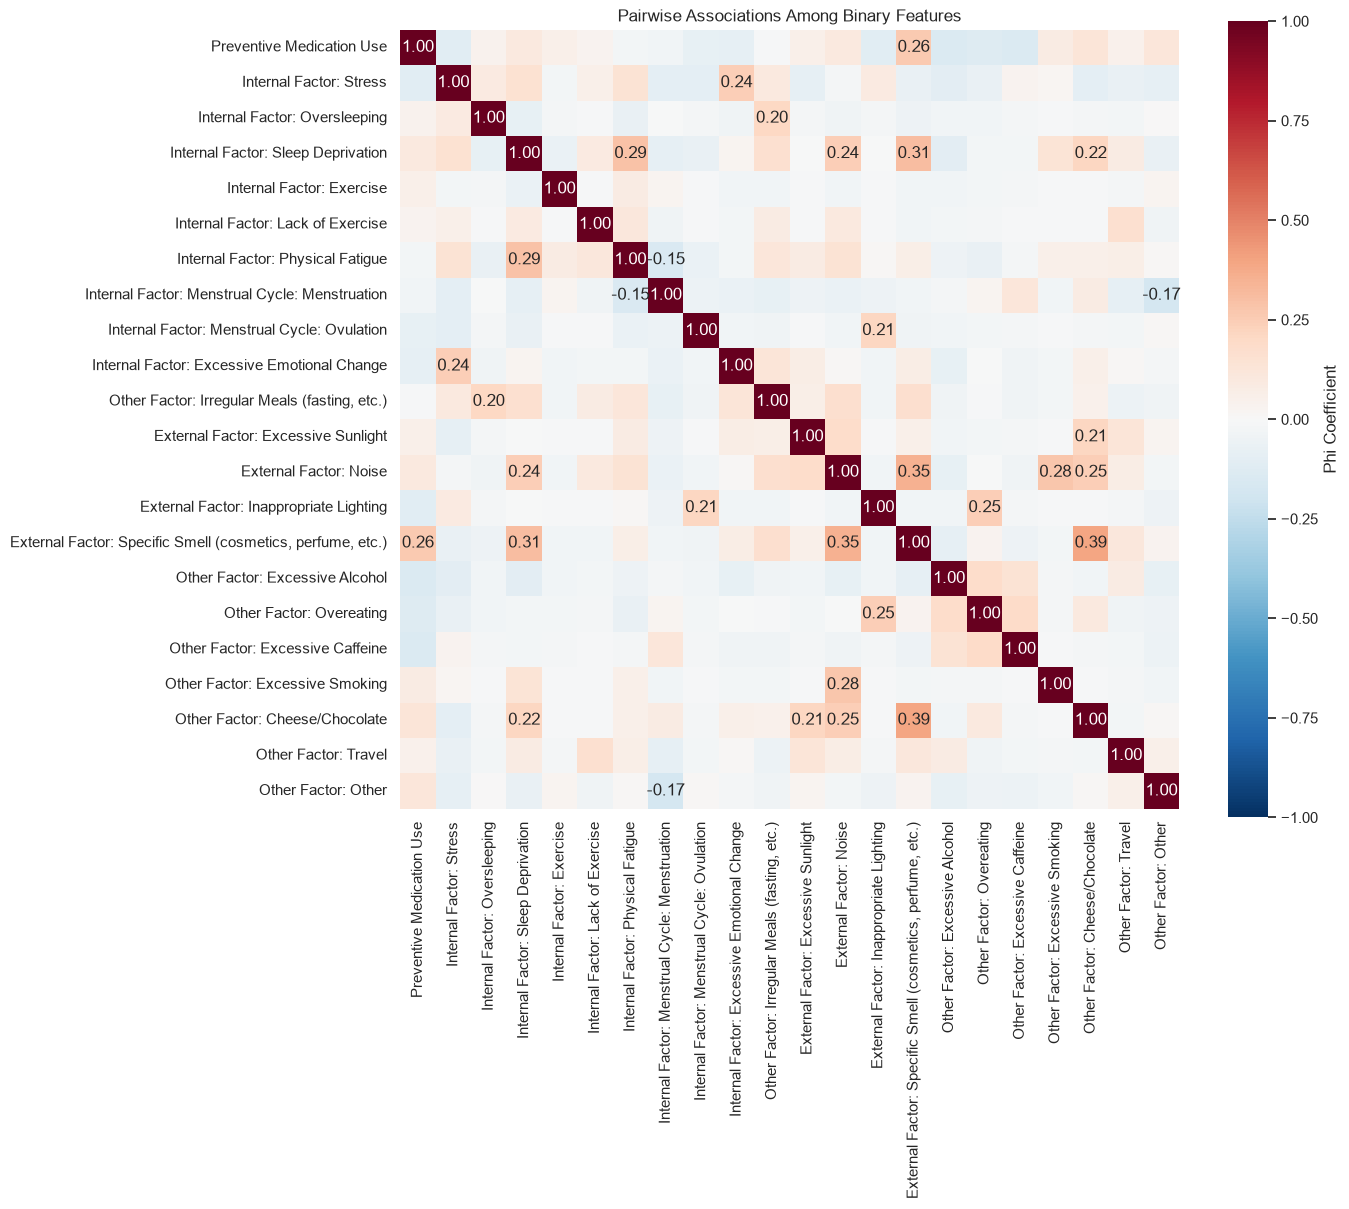

In [94]:
# Create custom annotation labels
# Show values where the absolute phi coefficient is >= 0.20 and <= -0.15, otherwise leave the cell blank
annot_labels = np.where(
    (phi_matrix >= 0.20) | (phi_matrix <= -0.15),
    np.vectorize(lambda x: f"{x:.2f}")(phi_matrix),
    ""
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    phi_matrix,
    annot=annot_labels,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Phi Coefficient"},
    square=True
)

plt.title("Pairwise Associations Among Binary Features")
plt.tight_layout()
plt.show()

### 7.3 Strongest Associations Among Binary Predictors

Identify predictor pairs with the strongest absolute phi coefficients to highlight potentially redundant or closely related variables.

In [95]:
# Extract unique predictor pairs
upper_triangle = np.triu(
    np.ones(phi_matrix.shape),
    k=1
).astype(bool)

phi_pairs = (
    phi_matrix
    .where(upper_triangle)
    .stack()
    .reset_index()
)

phi_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Phi"
]

phi_pairs["Absolute Phi"] = phi_pairs["Phi"].abs()

phi_pairs = phi_pairs.sort_values(
    "Absolute Phi",
    ascending=False
)

phi_pairs.head(15)

,Feature 1,Feature 2,Phi,Absolute Phi
327,"External Factor: Specific Smell (cosmetics, pe...",Other Factor: Cheese/Chocolate,0.390688,0.390688
278,External Factor: Noise,"External Factor: Specific Smell (cosmetics, pe...",0.352642,0.352642
80,Internal Factor: Sleep Deprivation,"External Factor: Specific Smell (cosmetics, pe...",0.306094,0.306094
72,Internal Factor: Sleep Deprivation,Internal Factor: Physical Fatigue,0.293251,0.293251
282,External Factor: Noise,Other Factor: Excessive Smoking,0.277889,0.277889
14,Preventive Medication Use,"External Factor: Specific Smell (cosmetics, pe...",0.263491,0.263491
302,External Factor: Inappropriate Lighting,Other Factor: Overeating,0.249967,0.249967
283,External Factor: Noise,Other Factor: Cheese/Chocolate,0.249707,0.249707
31,Internal Factor: Stress,Internal Factor: Excessive Emotional Change,0.244745,0.244745
78,Internal Factor: Sleep Deprivation,External Factor: Noise,0.242953,0.242953


### 7.4 Relationships Among Weather Predictors

Relationships among continuous weather predictors were examined to identify potential redundancy and multicollinearity before feature engineering and model development. Spearman correlations were used because they do not require a linear relationship or normally distributed variables.

Particular attention was given to relationships between the two atmospheric pressure measurements and between weather-change variables calculated across different temporal windows.

#### 7.3.1 Correlation Matrix

In [96]:
# Calculate Spearman correlations among weather predictors
weather_corr = weather_model_df[
    WEATHER_FEATURES
].corr(method="spearman")

weather_corr.round(2)

,temperature_2m,relative_humidity_2m,surface_pressure,pressure_msl,wind_speed_10m,wind_direction_10m,relative_humidity_change_24h,temperature_change_24h,pressure_msl_change_24h,surface_pressure_change_24h,...,wind_speed_10m_change_48h,wind_direction_10m_change_48h,relative_humidity_change_72h,temperature_change_72h,pressure_msl_change_72h,surface_pressure_change_72h,wind_speed_10m_change_72h,wind_direction_10m_change_72h,wind_direction_sin,wind_direction_cos
temperature_2m,1.00,0.41,-0.60,-0.64,-0.22,-0.36,0.10,0.16,-0.19,-0.19,...,-0.06,0.04,0.20,0.17,-0.14,-0.13,-0.07,-0.03,0.24,-0.26
relative_humidity_2m,0.41,1.00,-0.42,-0.42,-0.28,-0.43,0.43,0.14,-0.43,-0.43,...,-0.09,0.04,0.46,0.23,-0.21,-0.20,-0.13,-0.01,0.47,-0.27
surface_pressure,-0.60,-0.42,1.00,1.00,-0.08,0.12,-0.03,-0.02,0.39,0.40,...,-0.12,-0.03,-0.18,-0.05,0.53,0.53,-0.11,0.15,-0.02,0.10
pressure_msl,-0.64,-0.42,1.00,1.00,-0.06,0.14,-0.03,-0.03,0.39,0.39,...,-0.12,-0.04,-0.19,-0.05,0.52,0.52,-0.10,0.15,-0.03,0.11
wind_speed_10m,-0.22,-0.28,-0.08,-0.06,1.00,0.24,-0.23,-0.32,0.12,0.12,...,0.65,-0.03,-0.13,-0.21,-0.13,-0.14,0.67,-0.08,-0.28,0.22
wind_direction_10m,-0.36,-0.43,0.12,0.14,0.24,1.00,-0.24,-0.22,0.24,0.23,...,0.17,-0.09,-0.17,-0.14,-0.01,-0.01,0.17,-0.14,-0.71,0.34
relative_humidity_change_24h,0.10,0.43,-0.03,-0.03,-0.23,-0.24,1.00,0.34,-0.51,-0.51,...,-0.33,0.04,0.30,0.15,0.07,0.07,-0.29,0.02,0.21,-0.35
temperature_change_24h,0.16,0.14,-0.02,-0.03,-0.32,-0.22,0.34,1.00,-0.36,-0.35,...,-0.42,0.12,0.15,0.41,0.07,0.08,-0.37,0.07,0.14,-0.35
pressure_msl_change_24h,-0.19,-0.43,0.39,0.39,0.12,0.24,-0.51,-0.36,1.00,1.00,...,0.13,-0.01,-0.40,-0.33,0.39,0.39,0.14,0.12,-0.16,0.14
surface_pressure_change_24h,-0.19,-0.43,0.40,0.39,0.12,0.23,-0.51,-0.35,1.00,1.00,...,0.13,-0.00,-0.40,-0.33,0.39,0.39,0.14,0.12,-0.16,0.14


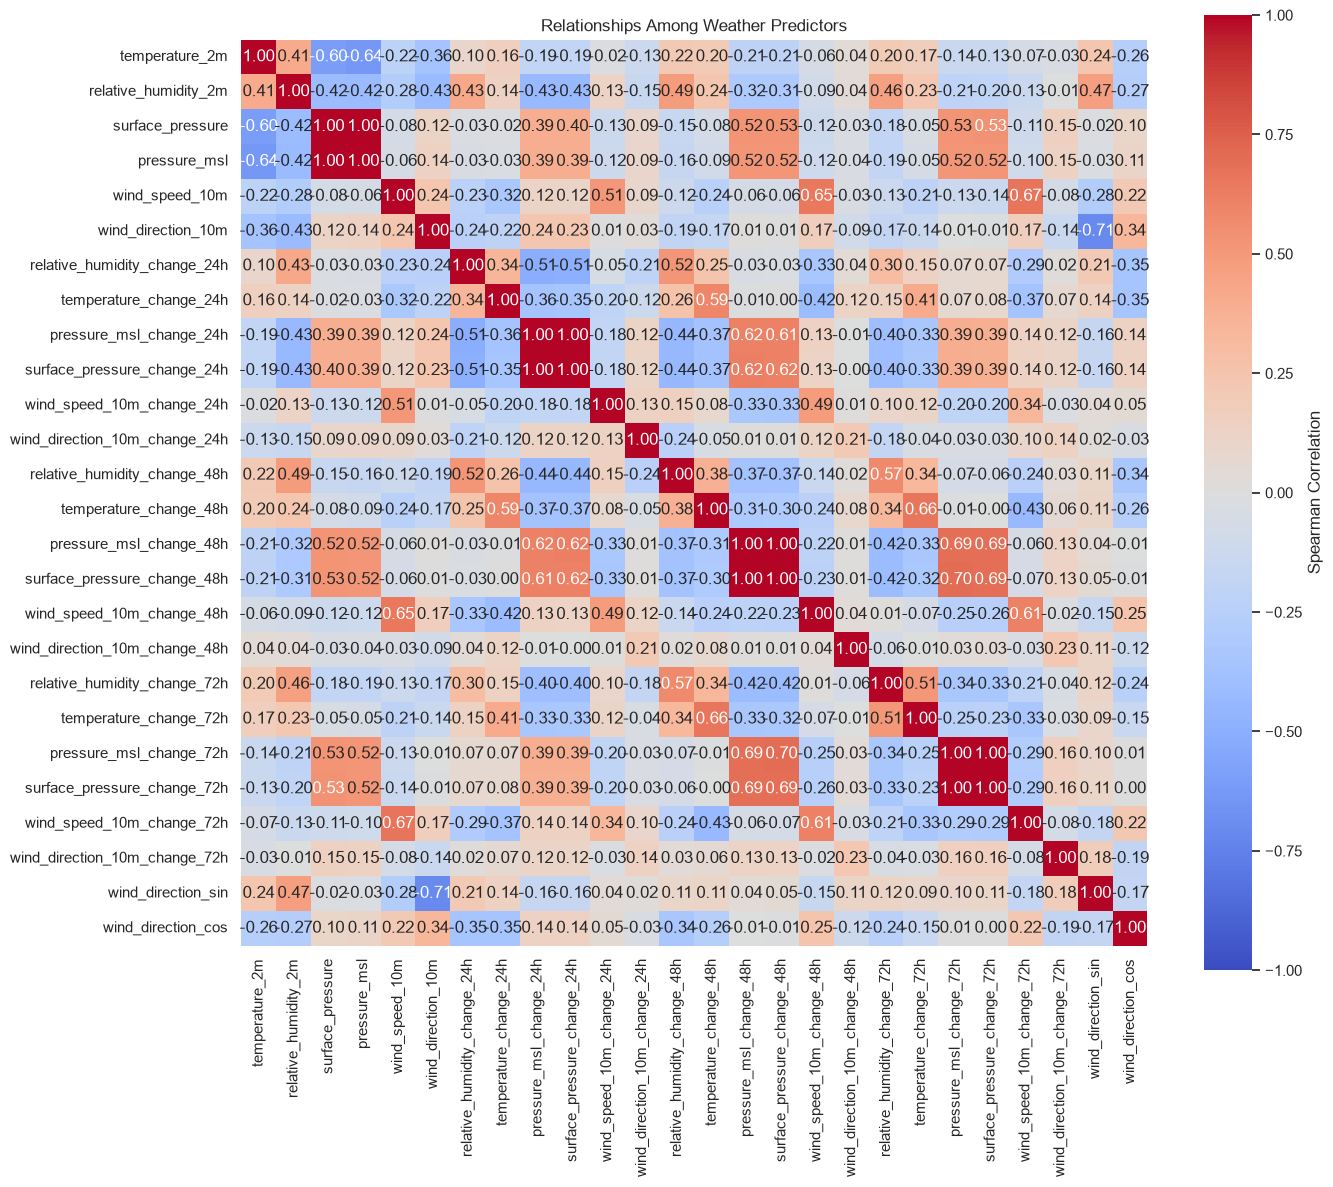

In [97]:
# Plot correlations among weather predictors
plt.figure(figsize=(14, 12))

sns.heatmap(
    weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Spearman Correlation"}
)

plt.title("Relationships Among Weather Predictors")
plt.tight_layout()
plt.show()

In [98]:
# Extract unique weather-feature pairs
weather_corr_pairs = []

for i, feature_1 in enumerate(weather_corr.columns):
    for j, feature_2 in enumerate(weather_corr.columns):

        if j <= i:
            continue

        correlation = weather_corr.loc[
            feature_1,
            feature_2
        ]

        weather_corr_pairs.append({
            "Feature 1": feature_1,
            "Feature 2": feature_2,
            "Spearman Correlation": correlation,
            "Absolute Correlation": abs(correlation),
        })

weather_corr_pairs = (
    pd.DataFrame(weather_corr_pairs)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

weather_corr_pairs.head(20)

,Feature 1,Feature 2,Spearman Correlation,Absolute Correlation
0,pressure_msl_change_24h,surface_pressure_change_24h,0.999772,0.999772
1,pressure_msl_change_48h,surface_pressure_change_48h,0.999747,0.999747
2,pressure_msl_change_72h,surface_pressure_change_72h,0.999669,0.999669
3,surface_pressure,pressure_msl,0.998456,0.998456
4,wind_direction_10m,wind_direction_sin,-0.705759,0.705759
5,surface_pressure_change_48h,pressure_msl_change_72h,0.697208,0.697208
6,surface_pressure_change_48h,surface_pressure_change_72h,0.693610,0.693610
7,pressure_msl_change_48h,pressure_msl_change_72h,0.693517,0.693517
8,pressure_msl_change_48h,surface_pressure_change_72h,0.689699,0.689699
9,wind_speed_10m,wind_speed_10m_change_72h,0.665623,0.665623


In [99]:
# Identify strongly correlated weather predictors
strong_weather_correlations = weather_corr_pairs.loc[
    weather_corr_pairs["Absolute Correlation"] >= 0.70
].copy()

strong_weather_correlations

,Feature 1,Feature 2,Spearman Correlation,Absolute Correlation
0,pressure_msl_change_24h,surface_pressure_change_24h,0.999772,0.999772
1,pressure_msl_change_48h,surface_pressure_change_48h,0.999747,0.999747
2,pressure_msl_change_72h,surface_pressure_change_72h,0.999669,0.999669
3,surface_pressure,pressure_msl,0.998456,0.998456
4,wind_direction_10m,wind_direction_sin,-0.705759,0.705759


### 7.5 Predictor Redundancy Summary

Pairwise relationships among predictors were examined to identify potentially redundant features before model development. Associations among binary predictors were evaluated using Phi coefficients, while relationships among continuous weather predictors were evaluated using Spearman correlations.

Strong pairwise relationships were treated as indicators of potential redundancy rather than automatic criteria for feature removal. Final decisions regarding correlated predictors will be made during feature engineering, considering statistical redundancy, interpretability, and relevance to the study's research questions.

## 8. EDA Summary

In [100]:
# Final EDA dataset summary
print(f"Observations: {weather_model_df.shape[0]}")
print(f"Columns: {weather_model_df.shape[1]}")

print("\nTarget distribution:")
display(
    weather_model_df[TARGET]
    .value_counts()
    .reindex(SEVERITY_ORDER)
    .to_frame("Count")
)

print("\nMissing values in candidate predictors:")
display(
    weather_model_df[WEATHER_FEATURES]
    .isna()
    .sum()
    .to_frame("Missing")
)

Observations: 302
Columns: 66

Target distribution:


,Count
Severity_VAS,
Mild,55
Moderate,138
Severe,109



Missing values in candidate predictors:


,Missing
temperature_2m,0
relative_humidity_2m,0
surface_pressure,0
pressure_msl,0
wind_speed_10m,0
wind_direction_10m,0
relative_humidity_change_24h,1
temperature_change_24h,1
pressure_msl_change_24h,1
surface_pressure_change_24h,1


### 8.1 Key Physiological Patterns — RQ2 (Which physiological factors are most predictive of migraine severity?)

The top physiological factors are stress, sleep deprivation, physical fatigue, and preventative medication use. 

Rationale:
- When examining prevalence of physiological factors by migraine severity
    - Higher percentages than the other internal factors
        - Important to note: moderate was the highest severity classification for stress, sleep deprivation, physical fatigue, and preventative medication use.
    - Menstruation was also a top performing factor as the fourth overall
        - Its highest severity classification was mild, while moderate was the lowest
- Statistical analysis:
    - Sleep deprivation was the most statistically significant (p-val 0.016) 
        - Stress (p-val 0.06), preventative medication use (p-val 0.068), and physical fatigue (p-val 0.076) didn't meet the traditionally statistically significant threshold, but were close
        - Other internal factors had p-vals much higher (>0.1)
    - Chi square values (test of independence): sleep depreivation (8.21), stress (5.61), preventative medication use (5.35), and physical fatigue (5.13)
        - Other factors had values <1, except for irregular meals (2.47)
    - Cramers V values (strength of association): sleep depreivation (0.16), stress (0.136), preventative medication use (0.133), physical fatigue (0.130)
        - Other internal factors had values much lower (<0.1)

None of the factors reached statistical significance after FDR correction.
- Could indicate severity is a combination of different types of factors?


### 8.2 Key Environmental Factors and Patterns — RQ3 (Which environmental factors are most predictive of migraine severity?)

**External Factors**
- Odors and noise were the most prevalent
- Specifically occurring in association with moderate and severe migraines

**Time of Day**
- Migraines tend to occur more often in the morning
    - Over 50% of moderate and severe migraines occur in the morning
- Average start times for moderate and severe migraines were around 10am and 9am, respectively
    - Mild start time was around noon (12pm)

**Historical Weather**
- Variables used: temp, relative humidity, surface pressure, and mean sea-level pressure
- Surface and mean sea-level pressures produced very similar results
    - Need to remove one of them 
- Temperature and relative humidity generally increased with migraine intensity, while atmospheric pressure decreased with migraine severity
    - Severe episodes occurred when weather was warmer, more humid, and lower atmospheric pressure
    - ***NOTE:*** These results reflect basic weather concepts where low pressure weather systems tend to bring in wetter, warmer weather conditions
    - Weather changes were pretty similar across mild, moderate, and severe migraines, with a lot of overlap between the groups.
- When comparing 24h, 48h, and 72h windows of weather, most weather changes centered around 0
    - Humidity showed some of the biggest changes, especially over the 48h and 72h windows
    - Temperature changes were generally small, but tended to decrease slightly over the longer time windows
    - Pressure changes were also similar across severities, but larger changes were seen over 48–72 hours
    - *How much the weather changed may be more useful than whether it went up or down*
- None of the raw weather variables or the 24-, 48-, or 72-hour weather-change variables demonstrated statistically significant differences across Mild, Moderate, and Severe migraine episodes based on Kruskal–Wallis testing
    - No environmental variable remained significant after Benjamini–Hochberg correction for multiple comparisons
    - Atmospheric pressure-msl (0.106) and relative humidity (0.111) had the lowest unadjusted pvals
- Findings suggest individual variables do not have a strong enough influence but may compound one another when combined, suggesting multivariable modleing 






### 8.3 Lifestyle and Behavioral Factors

- "Other" had the highest percentages of occurrence with migraine severity
    - This category is currently too vague
    - The rest had percentages less than 10%
- Statistical analysis:
    - Excessive caffeine was the most statistically significant (p-val 0.049) with a Chi square value of 6.029 and Cramer's V 0.141

### 8.4 Summary of Migraine Features R1 (To what extent can migraine severity be predicted using physiological and environmental factors?)

- Most significant factors were sleep deprivation (0.016) and excessive caffeine (0.049)
    - Sleep deprivation had Chi square and Cramers V values of 8.21 and 0.165, respectively
    - Excessive caffeine had Chi square and Cramers V values of 6.063and 0.141, respectively
- Stress, Preventive Medication Use, and Physical Fatigue did not meed the traditional statistical significance threshold of pval<0.05 but had values <0.1 and had Chi square and Cramer's V values that could indicate their importance
    - Stress: pval (0.06), Chi squared (5.61), Cramer's V (0.136)
    - Preventative Medication Use: pval (0.07), Chi squared (5.35), Cramer's V (0.133)
    - Physical Fatigue: pval (0.08), Chi squared (5.13), Cramer's V (0.130)



### 8.5 Relationships Among Predictors R5 (What is the relative contribution of physiological versus environmental factors in predicting migraine severity?)

Strongest associated factors:

- Odor and Cheese/Chocolate (0.39)
- Noise and Odor (0.35)
- Sleep deprivation and Odor (0.31)
- Sleep deprivations and Physical Fatigue (0.29)
- Noise and Excessive Smoking (0.28)
- Preventive Medication Use and Odor (0.26)
- Inappropriate lighting and Overeating (0.25)
- Noise and Cheese/Chocolate (0.25)
- Stress and Excessive Emotional Change (0.24)
- Sleep Deprivation and Noise (0.24)
- Sleep Deprivation and Cheese/Chocolate (0.22)
- Ovulation and Inappropriate Lighting (0.21)
- Excessive Sunlight and Cheese/Chocolate (0.21)
- Oversleeping and Irregular Meals (0.20)

*All these show **moderate** associations*


### 8.4 Implications for Feature Engineering

The EDA identified several considerations that will guide feature engineering prior to model development.

First, mean sea-level pressure and surface pressure showed near-perfect correlations. The raw measures were highly correlated (rₛ = 0.998), and their corresponding 24h, 48h, and 72h change variables were similarly correlated (rₛ > 0.999). Retaining both pressure representations would therefore introduce substantial redundancy. One pressure representation will be selected during feature engineering based on interpretability and relevance to the migraine literature.

Weather-change features measured across 24h, 48h, and 72h windows showed moderate correlations because the time periods overlap. These features will initially be evaluated separately rather than automatically removed, allowing subsequent modeling to determine whether different pre-migraine windows provide distinct predictive information.

Associations among binary predictors were generally weak to moderate. The strongest observed Phi coefficient was approximately 0.39, suggesting that severe redundancy among the physiological, lifestyle, and non-weather environmental binary predictors is limited.

The target distribution also showed moderate class imbalance, with 55 Mild, 138 Moderate, and 109 Severe migraine episodes. This imbalance will be considered during model training and evaluation.

Finally, missingness in the derived weather-change features was minimal and resulted from unavailable historical observations at the beginning of the weather time series. These observations will be handled during preprocessing without removing otherwise usable migraine episodes.

### 8.5 Implications for Modeling

The EDA suggests that migraine severity is unlikely to be predicted by a single dominant factor. Most predictors showed weak individual relationships with severity, but combinations of physiological, lifestyle, temporal, and environmental factors may provide greater predictive value. For this reason, the model development phase will use multivariable ML methods capable of identifying combined effects, nonlinear relationships, and interactins among predictors.

Model performance will be compared across three feature sets: physiological and lifestyle factors, environmental and temporal factors, and a combined set containing all retained predictors. This comparison will help determine whether environmental information improves severity prediction beyond patient reported physiological and lifestyle factors.

A dummy classifier will first be used to establish a minimum performance baseline. Multinomial logistic regression will then provide an interpretable statistical baseline, while random forest and XGBoost will be evaluated for their ability to identify more complex patterns in the data.

Because multiple migraine episodes were most likely recorded by the same particiapnt, observations will be divided into training and testing sets by participant ID. This will prevent episodes from the same participant from appearing in both sets and reduce risk of data leakage. Grouped cross-validation will also be used during model training and hyperparameter tuning.

The target distribution is moderately imbalanced, particularly because mild episodes are less common than moderate and severe episodes. THerefore, model Performance will evaluated primarily using marco F1 score and balanced accuracy rather than accuracy alone. Class-specific precision, recall, F1 scores, and confusion matrices will also be examined to determine how well each severity category is identified. Class weighting will be evaluated before considering resampling methods such as SMOTE.

Preprocessing and feature engineering will be performed within the model-training pipeline. THis will include handling the small number of missing weather change values, encoding categorical values, scaling continuous variables when required, and removing redundant atmospheric pressure measurements. Absolute weather change features will also be considered so that the models can evaluate both how much the weather changed and whether it increased or decreased.

The final model will be selected based on cross validation performance and then evaluated once on the held out test set. Feature importance, permutation importance, model coefficients, or SHAP values will be used as appropriate to identify which predictors contribute most strongly to severity classification.